./results/merged/*.txt
     size  algorithm     ratio
0     100   MeDiH-BL  0.784381
1     100  MeDiH-BLC  0.819582
2     100   MeDiH-MM  0.994319
3     200   MeDiH-BL  1.395850
4     200  MeDiH-BLC  1.403393
5     200   MeDiH-MM  0.955100
6    1000   MeDiH-BL  0.897842
7    1000  MeDiH-BLC  0.927628
8    1000   MeDiH-MM  0.820342
9    2000   MeDiH-BL  0.721529
10   2000  MeDiH-BLC  0.769715
11   2000   MeDiH-MM  0.816123
12   4000   MeDiH-BL  0.651458
13   4000  MeDiH-BLC  0.675408
14   4000   MeDiH-MM  0.871323
15   8000   MeDiH-BL  0.557287
16   8000  MeDiH-BLC  0.565674
17   8000   MeDiH-MM  0.925050
18  10000   MeDiH-BL  0.558652
19  10000  MeDiH-BLC  0.546780
20  10000   MeDiH-MM  0.929024
21  15000   MeDiH-BL  0.508102
22  15000  MeDiH-BLC  0.511141
23  15000   MeDiH-MM  1.000208
24  20000   MeDiH-BL  0.483772
25  20000  MeDiH-BLC  0.496828
26  20000   MeDiH-MM  1.031585
27  25000   MeDiH-BL  0.471282
28  25000  MeDiH-BLC  0.486042
29  25000   MeDiH-MM  1.050795
30  30000   MeDi

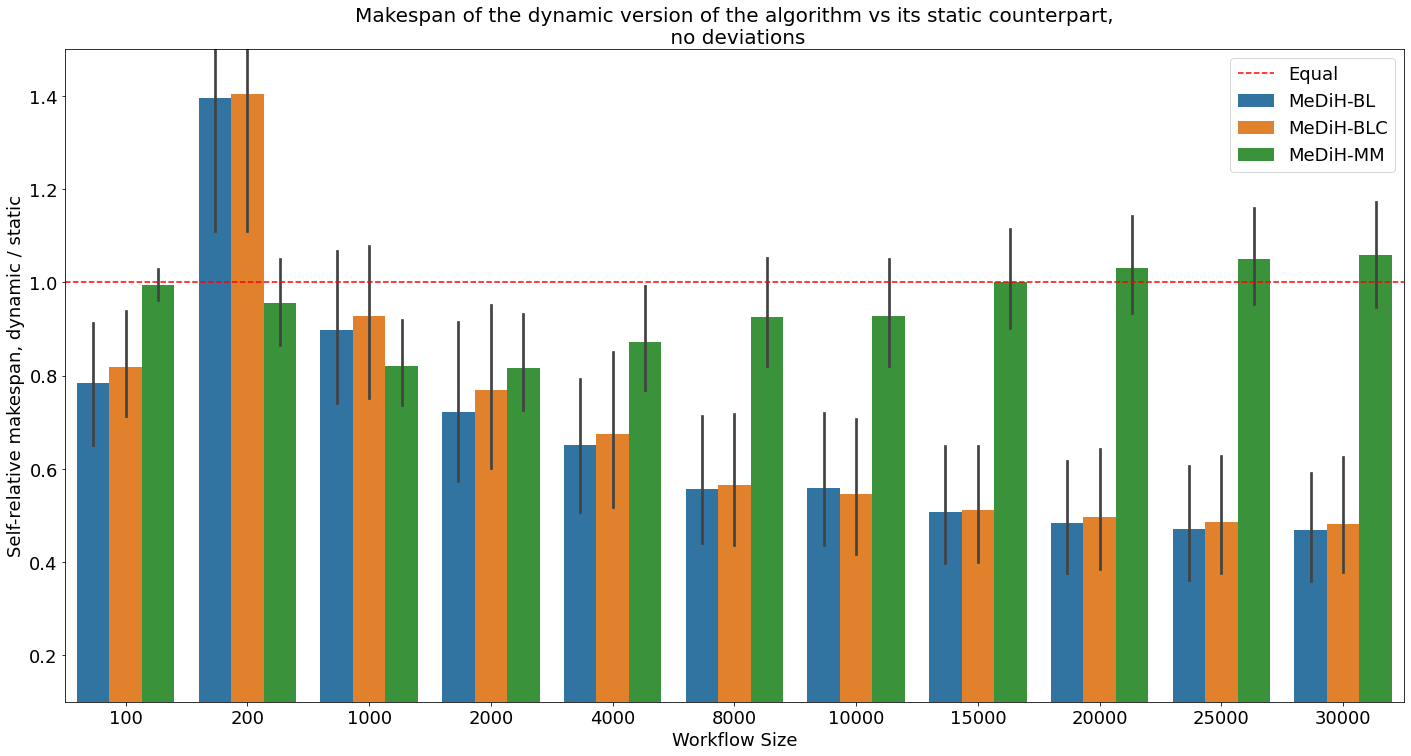

./param-study-pcsp/merged/*.txt


KeyError: ('A1', 'pspw+2')

KeyError: ('A1', 'pspw+2')

In [7]:
%run ChartsCommon.ipynb
%run ChartsToBaseline.ipynb

In [3]:
def size_category(size):
    if size <= 200:
        return 'small'
    elif 1000 <= size <= 8000:
        return 'middle'
    elif 10000 <= size <= 18000:
        return 'large'
    elif 20000 <= size <= 30000:
        return 'largest'
    else:
        return 'other'

size_order = ['small', 'middle', 'large', 'largest']

./results-13-07/merged_final/10pw3/*.txt


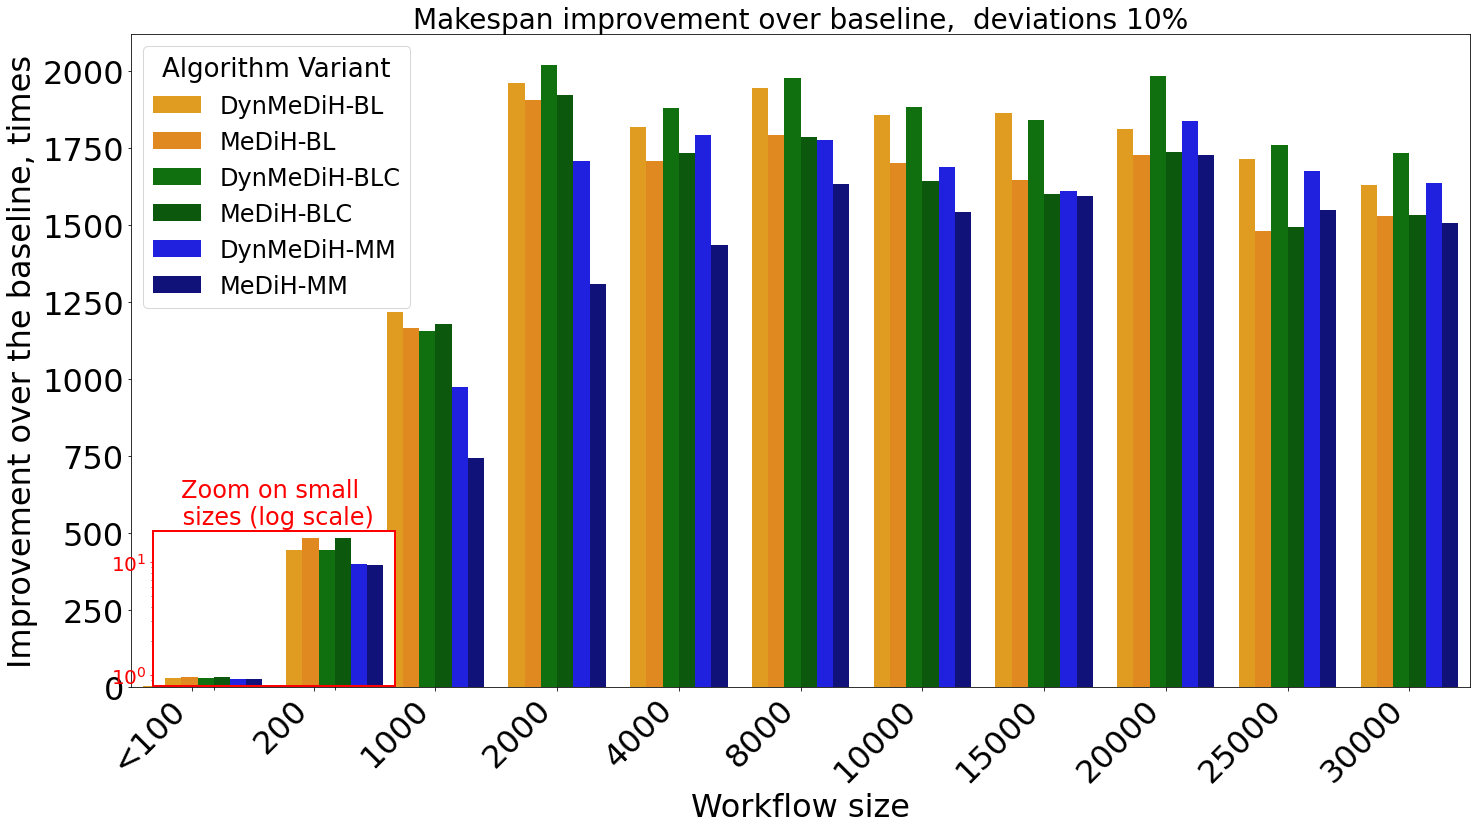

     size                   alg_rel        ratio
0     100    MeDiH-BL - dyn_vs_base     0.949927
1     100   MeDiH-BL - stat_vs_base     0.964303
2     100   MeDiH-BLC - dyn_vs_base     0.941412
3     100  MeDiH-BLC - stat_vs_base     0.963891
4     100    MeDiH-MM - dyn_vs_base     0.932525
..    ...                       ...          ...
61  30000   MeDiH-BL - stat_vs_base  1528.869576
62  30000   MeDiH-BLC - dyn_vs_base  1735.386199
63  30000  MeDiH-BLC - stat_vs_base  1533.083993
64  30000    MeDiH-MM - dyn_vs_base  1638.092781
65  30000   MeDiH-MM - stat_vs_base  1507.740945

[66 rows x 3 columns]
alg_rel
MeDiH-BL - dyn_vs_base      563.636462
MeDiH-BL - stat_vs_base     541.768076
MeDiH-BLC - dyn_vs_base     573.268126
MeDiH-BLC - stat_vs_base    541.373165
MeDiH-MM - dyn_vs_base      513.946795
MeDiH-MM - stat_vs_base     460.654264
Name: ratio, dtype: float64
    algorithm size_group     ratio
3    MeDiH-BL      small  1.157027
2    MeDiH-BL     middle  0.947452
0    MeDiH-BL 

In [16]:
path = "./results-13-07/merged_final/10pw3/*.txt"
print(path)

patterndevs = r'^(BASE|A\d+)-(\d\ddev)'

dfs=read_dfs(path,patterndevs, 2)


labels = ['A1', 'A2', 'A3', 'BASE']
dfsVar1 = [dfs[('A1','10dev')], dfs[('A2','10dev')], dfs[('A3','10dev')], dfs[('BASE','10dev')]]
#print(dfsVar1)
merged_df_var1 = merge_correct_columns(dfsVar1, labels)
#print(merged_df_var1)
plot_df = buld_plot_df(merged_df_var1)
plot_df = plot_df[plot_df["size"]!= 18000]


plotDynAndStaticVsBase(plot_df, "deviations 10%", "Makespan improvement over baseline, ", ['stat_vs_base', 'dyn_vs_base'])#

allInternals = plot_df[plot_df['relation']=='internal']
allInternals = allInternals.copy()
#print(allInternals.to_string())
# Add a new column for size group
allInternals['size_group'] = allInternals['size'].apply(size_category)
# Filter only valid categories
filtered = allInternals[allInternals['size_group'] != 'other']
# Group by algorithm and size_group, then compute geometric mean
result = filtered.groupby(['algorithm', 'size_group'])['ratio'].agg(gmean).reset_index()

# Optionally, sort the result

result['size_group'] = pd.Categorical(result['size_group'], categories=size_order, ordered=True)
result = result.sort_values(['algorithm', 'size_group'])

print(result)

by_algo = allInternals.groupby('algorithm')['ratio'].agg(gmean).reset_index()
print(by_algo)

./results-13-07/merged_final/10pw3/*.txt
      size             wf_name      inp_size  relation     ratio  algorithm
821    200     chipseq_200.dot    5058052541  internal  1.336214  MeDiH-BLC
827   1000    atacseq_1000.dot   11809629756  internal  1.132973  MeDiH-BLC
849    200     atacseq_200.dot   11809629756  internal  1.329763  MeDiH-BLC
853    200     chipseq_200.dot   32978181418  internal  1.170849  MeDiH-BLC
859    200     chipseq_200.dot    4807293396  internal  1.004299  MeDiH-BLC
860    200     chipseq_200.dot    3793245764  internal  1.317454  MeDiH-BLC
895    200   methylseq_200.dot  110641579976  internal  1.016705  MeDiH-BLC
930    200     atacseq_200.dot   14091675276  internal  1.365954  MeDiH-BLC
943    200     chipseq_200.dot    4605965334  internal  1.273675  MeDiH-BLC
946    200     atacseq_200.dot    3908761308  internal  1.413798  MeDiH-BLC
948    200     atacseq_200.dot    2223941232  internal  1.030078  MeDiH-BLC
954    200   methylseq_200.dot    8885797810  i

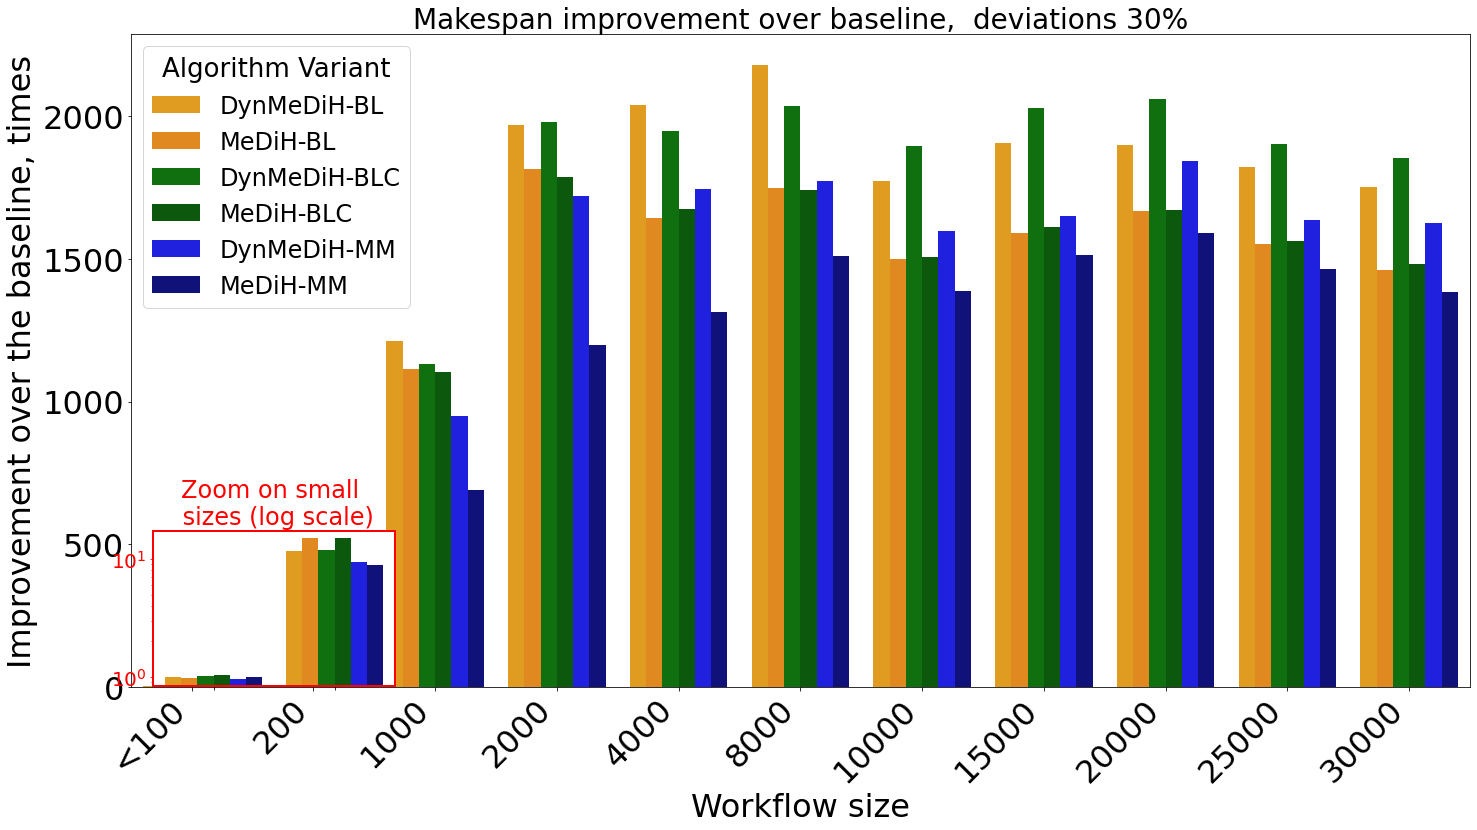

     size                   alg_rel        ratio
0     100    MeDiH-BL - dyn_vs_base     0.985201
1     100   MeDiH-BL - stat_vs_base     0.981770
2     100   MeDiH-BLC - dyn_vs_base     1.015397
3     100  MeDiH-BLC - stat_vs_base     1.041790
4     100    MeDiH-MM - dyn_vs_base     0.955774
..    ...                       ...          ...
61  30000   MeDiH-BL - stat_vs_base  1462.887959
62  30000   MeDiH-BLC - dyn_vs_base  1852.999479
63  30000  MeDiH-BLC - stat_vs_base  1481.150880
64  30000    MeDiH-MM - dyn_vs_base  1626.416931
65  30000   MeDiH-MM - stat_vs_base  1384.476819

[66 rows x 3 columns]
alg_rel
MeDiH-BL - dyn_vs_base      580.018385
MeDiH-BL - stat_vs_base     521.980846
MeDiH-BLC - dyn_vs_base     589.976755
MeDiH-BLC - stat_vs_base    526.448054
MeDiH-MM - dyn_vs_base      508.620333
MeDiH-MM - stat_vs_base     432.230992
Name: ratio, dtype: float64
    algorithm size_group     ratio
3    MeDiH-BL      small  1.168978
2    MeDiH-BL     middle  0.861420
0    MeDiH-BL 

In [17]:
path = "./results-13-07/merged_final/10pw3/*.txt"
print(path)

patterndevs = r'^(BASE|A\d+)-(\d\ddev)'

dfs=read_dfs(path,patterndevs, 2)


dfsVar1 = [dfs[('A1','30dev')], dfs[('A2','30dev')], dfs[('A3','30dev')], dfs[('BASE','30dev')]]
#print(dfsVar1)
merged_df_var1 = merge_correct_columns(dfsVar1, labels)
#print(merged_df_var1)
plot_df = buld_plot_df(merged_df_var1)
plot_df = plot_df[plot_df["size"]!= 18000]
#print(plot_df[(plot_df['relation'] == 'internal') & (plot_df['algorithm'] == 'MeDiH-BLC') &  ('eager' not it plot_df['wf_name'] ) & (plot_df['ratio'] > 1) ].to_string()) #& (plot_df['size'] >= 1000)& (plot_df['size'] <= 8000)].to_string())
print(plot_df[
    (plot_df['relation'] == 'internal') &
    (plot_df['algorithm'] == 'MeDiH-BLC') &
    (~plot_df['wf_name'].str.contains('eager')) &
    (plot_df['ratio'] > 1)
].to_string())


plotDynAndStaticVsBase(plot_df, "deviations 30%", "Makespan improvement over baseline, ", ['stat_vs_base', 'dyn_vs_base'])#

allInternals = plot_df[plot_df['relation']=='internal']
allInternals = allInternals.copy()
#print(allInternals.to_string())
# Add a new column for size group
allInternals['size_group'] = allInternals['size'].apply(size_category)
# Filter only valid categories
filtered = allInternals[allInternals['size_group'] != 'other']
# Group by algorithm and size_group, then compute geometric mean
result = filtered.groupby(['algorithm', 'size_group'])['ratio'].agg(gmean).reset_index()

# Optionally, sort the result

result['size_group'] = pd.Categorical(result['size_group'], categories=size_order, ordered=True)
result = result.sort_values(['algorithm', 'size_group'])

print(result)

result2 = filtered.groupby(['algorithm', 'size'])['ratio'].agg(gmean).reset_index()
print("!!!", result2)

by_algo = allInternals.groupby('algorithm')['ratio'].agg(gmean).reset_index()
print(by_algo)

./results-13-07/merged_final/10pw3/*.txt
      size          wf_name     inp_size  relation     ratio algorithm
5     1000   eager_1000.dot  25705994498  internal  1.665107  MeDiH-BL
38    8000   eager_8000.dot  19075314980  internal  1.574819  MeDiH-BL
49    8000   eager_8000.dot  19132169434  internal  1.869185  MeDiH-BL
138    200  atacseq_200.dot   2223941232  internal  2.481475  MeDiH-BL
162   1000   eager_1000.dot   8330435694  internal  1.680617  MeDiH-BL
170   4000   eager_4000.dot  14754556884  internal  1.635604  MeDiH-BL
185   2000   eager_2000.dot  19075314980  internal  1.586879  MeDiH-BL
208    200    eager_200.dot  19075314980  internal  1.783281  MeDiH-BL
211  15000  eager_15000.dot   8330435694  internal  1.539385  MeDiH-BL
236    200    eager_200.dot  19132169434  internal  1.995228  MeDiH-BL
272    200    eager_200.dot   8330435694  internal  2.207463  MeDiH-BL


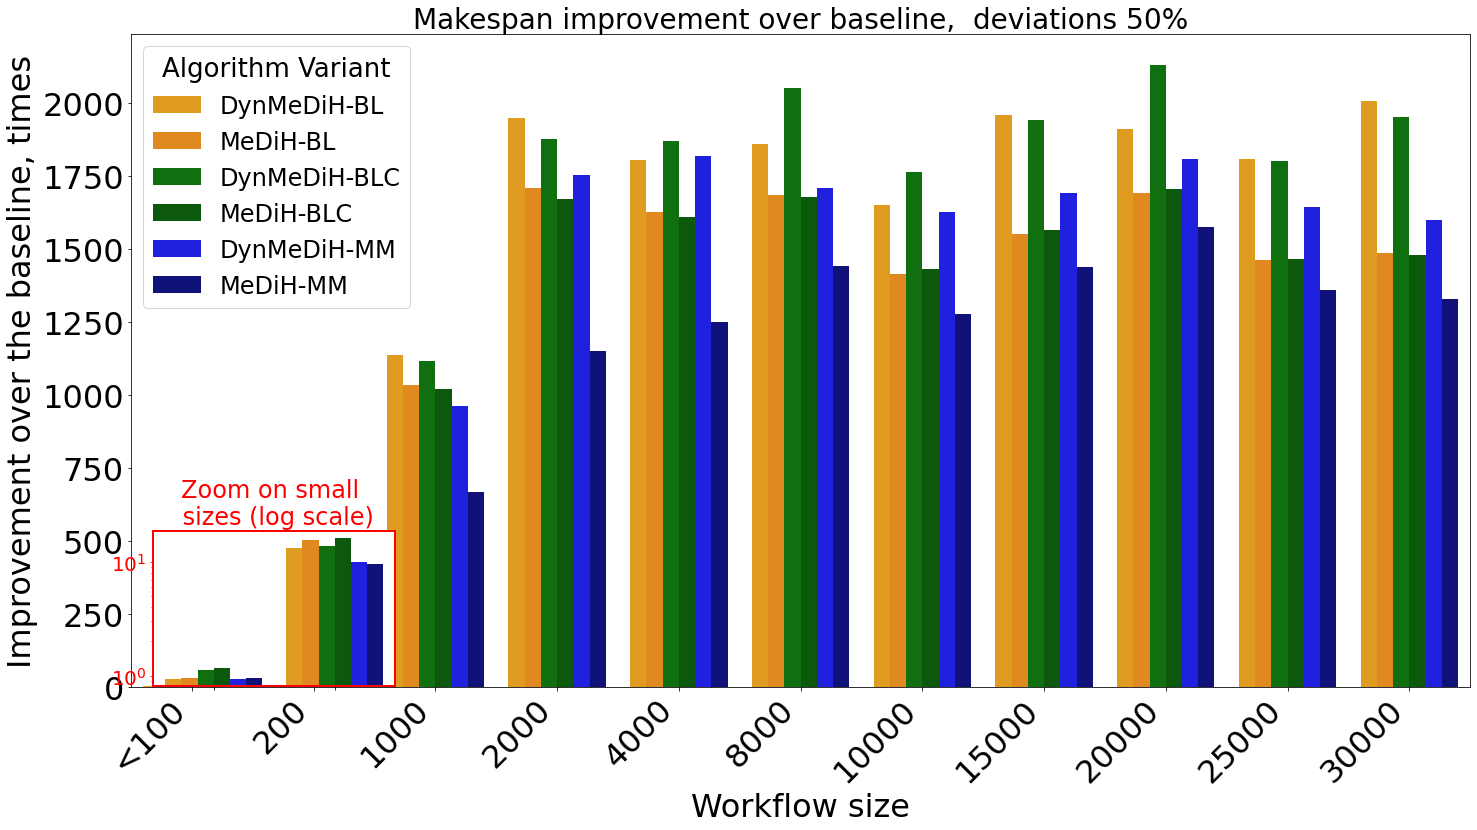

     size                   alg_rel        ratio
0     100    MeDiH-BL - dyn_vs_base     0.937054
1     100   MeDiH-BL - stat_vs_base     0.964020
2     100   MeDiH-BLC - dyn_vs_base     1.118208
3     100  MeDiH-BLC - stat_vs_base     1.174347
4     100    MeDiH-MM - dyn_vs_base     0.938103
..    ...                       ...          ...
61  30000   MeDiH-BL - stat_vs_base  1486.774842
62  30000   MeDiH-BLC - dyn_vs_base  1951.797516
63  30000  MeDiH-BLC - stat_vs_base  1479.303508
64  30000    MeDiH-MM - dyn_vs_base  1601.320321
65  30000   MeDiH-MM - stat_vs_base  1328.300388

[66 rows x 3 columns]
alg_rel
MeDiH-BL - dyn_vs_base      569.982391
MeDiH-BL - stat_vs_base     508.210622
MeDiH-BLC - dyn_vs_base     593.187068
MeDiH-BLC - stat_vs_base    518.960445
MeDiH-MM - dyn_vs_base      512.917019
MeDiH-MM - stat_vs_base     417.231165
Name: ratio, dtype: float64
    algorithm size_group     ratio
3    MeDiH-BL      small  1.115086
2    MeDiH-BL     middle  0.897823
0    MeDiH-BL 

In [18]:
path = "./results-13-07/merged_final/10pw3/*.txt"
print(path)

patterndevs = r'^(BASE|A\d+)-(\d\ddev)'

dfs=read_dfs(path,patterndevs, 2)


dfsVar1 = [dfs[('A1','50dev')], dfs[('A2','50dev')], dfs[('A3','50dev')], dfs[('BASE','50dev')]]
#print(dfsVar1)
merged_df_var1 = merge_correct_columns(dfsVar1, labels)
#print(merged_df_var1)
plot_df = buld_plot_df(merged_df_var1)
plot_df = plot_df[plot_df["size"]!= 18000]

print(plot_df[
    (plot_df['relation'] == 'internal') &
    (plot_df['algorithm'] == 'MeDiH-BL') 
   # & (~plot_df['wf_name'].str.contains('eager')) 
   & (plot_df['ratio'] > 1.5)
].to_string())

plotDynAndStaticVsBase(plot_df, "deviations 50%", "Makespan improvement over baseline, ", ['stat_vs_base', 'dyn_vs_base'])#

allInternals = plot_df[plot_df['relation']=='internal']
allInternals = allInternals.copy()
#print(allInternals.to_string())
# Add a new column for size group
allInternals['size_group'] = allInternals['size'].apply(size_category)
# Filter only valid categories
filtered = allInternals[allInternals['size_group'] != 'other']
# Group by algorithm and size_group, then compute geometric mean
result = filtered.groupby(['algorithm', 'size_group'])['ratio'].agg(gmean).reset_index()

# Optionally, sort the result

result['size_group'] = pd.Categorical(result['size_group'], categories=size_order, ordered=True)
result = result.sort_values(['algorithm', 'size_group'])

print(result)

result2 = filtered.groupby(['algorithm', 'size'])['ratio'].agg(gmean).reset_index()
print("!!!", result2)

by_algo = allInternals.groupby('algorithm')['ratio'].agg(gmean).reset_index()
print(by_algo)


./results-3-12/merged/*.txt
No match found. A3-bdev.txt
No match found. BASE-dev.txt
No match found. A2-dev.txt
No match found. BASE-30dev.txt
No match found. A3-dev.txt
No match found. A1-30dev.txt
No match found. A3-30dev.txt
No match found. A1-dev.txt
No match found. A2-bdev.txt
No match found. A2-30dev.txt
No match found. A1-bdev.txt
No match found. BASE-bdev.txt
[                 wf_name     inp_size       ms_1_A1       ms_2_A1
0      atacseq_30000.dot  14091675276  1.421259e+09  1.583728e+09
1      chipseq_15000.dot  41366257414  3.256855e+09  7.547922e+09
2    methylseq_15000.dot   6761426956  1.221635e+08  4.752229e+08
3      atacseq_15000.dot   3908761308  2.049557e+08  1.629076e+08
4         eager_1000.dot  25705994498  4.168264e+07  2.253165e+07
..                   ...          ...           ...           ...
245    chipseq_30000.dot   3793245764  6.285083e+08  6.327128e+08
246   methylseq_1000.dot   8885797810  1.126641e+07  1.385122e+07
247  methylseq_10000.dot  170272570

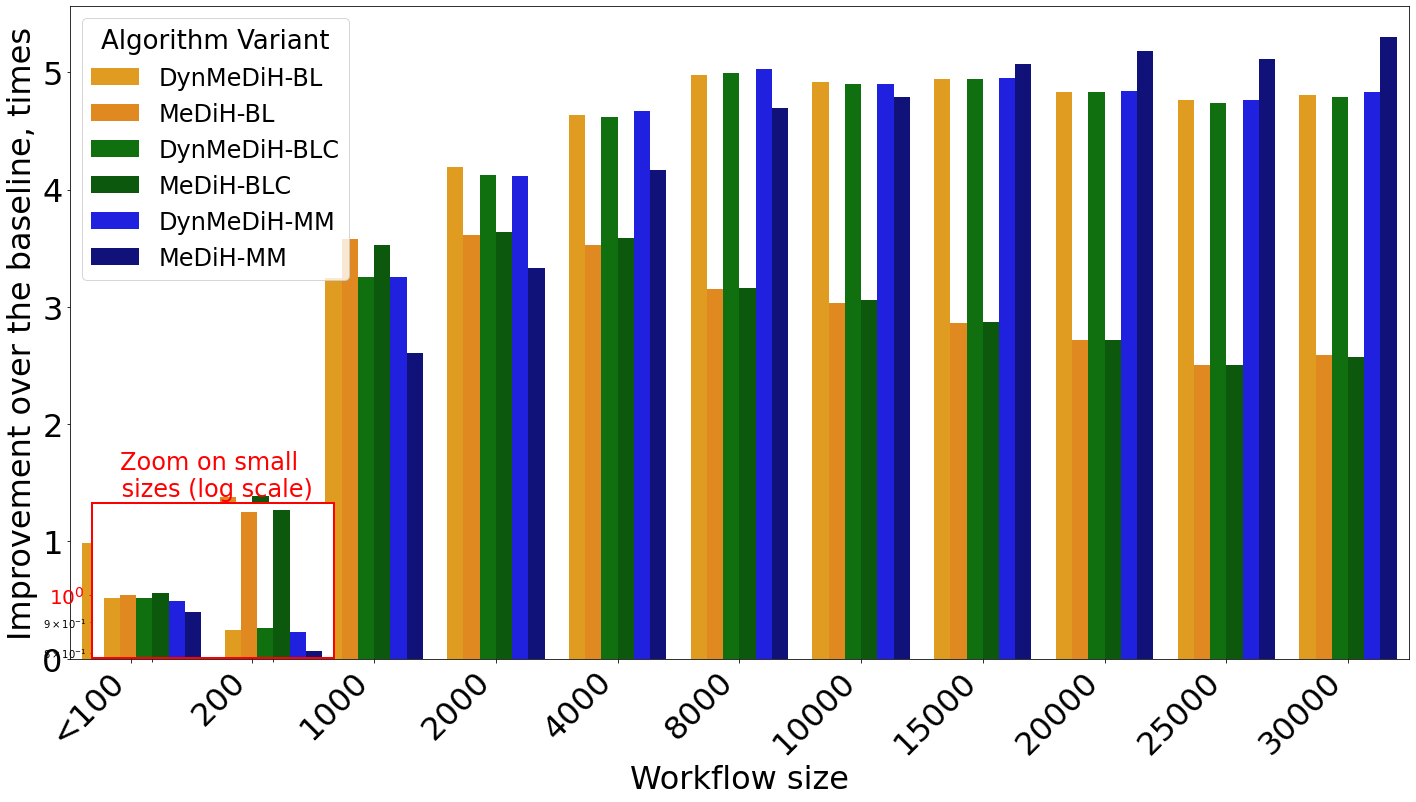

     size                   alg_rel     ratio
0     100    MeDiH-BL - dyn_vs_base  0.988959
1     100   MeDiH-BL - stat_vs_base  1.000000
2     100   MeDiH-BLC - dyn_vs_base  0.988959
3     100  MeDiH-BLC - stat_vs_base  1.006844
4     100    MeDiH-MM - dyn_vs_base  0.976487
..    ...                       ...       ...
61  30000   MeDiH-BL - stat_vs_base  2.592988
62  30000   MeDiH-BLC - dyn_vs_base  4.790581
63  30000  MeDiH-BLC - stat_vs_base  2.574718
64  30000    MeDiH-MM - dyn_vs_base  4.837365
65  30000   MeDiH-MM - stat_vs_base  5.298267

[66 rows x 3 columns]
alg_rel
MeDiH-BL - dyn_vs_base      3.412785
MeDiH-BL - stat_vs_base     2.556083
MeDiH-BLC - dyn_vs_base     3.406148
MeDiH-BLC - stat_vs_base    2.562611
MeDiH-MM - dyn_vs_base      3.407657
MeDiH-MM - stat_vs_base     3.256870
Name: ratio, dtype: float64
    algorithm size_group     ratio
3    MeDiH-BL      small  1.372156
2    MeDiH-BL     middle  0.822871
0    MeDiH-BL      large  0.597148
1    MeDiH-BL    largest  0

In [3]:
#path = "./results-13-07/nodevs/merged/*.txt"
#path = "./results/merged/*.txt"
path = "./results-3-12/merged/*.txt"
print(path)

patterndevs = r'^(BASE|A\d+)-(ndev)'

dfs=read_dfs(path,patterndevs, 2)


dfsVar1 = [dfs[('A1','ndev')], dfs[('A2','ndev')], dfs[('A3','ndev')], dfs[('BASE','ndev')]]
#print(dfsVar1)
merged_df_var1 = merge_correct_columns(dfsVar1, labels)
#print(merged_df_var1)
plot_df = buld_plot_df(merged_df_var1)
plot_df = plot_df[plot_df["size"]!= 18000]

#print(plot_df)
#print(plot_df[
#    (plot_df['relation'] == 'internal') &
#    (plot_df['algorithm'] == 'MeDiH-BL') 
#   # & (~plot_df['wf_name'].str.contains('eager')) 
#   & (plot_df['ratio'] > 1.5)
#].to_string())
plot_df.to_csv('plotdf.csv')


plotDynAndStaticVsBase(plot_df, "no deviations", "Makespan improvement over baseline, ", ['stat_vs_base', 'dyn_vs_base'])#

allInternals = plot_df[plot_df['relation']=='internal']
allInternals = allInternals.copy()
#print(allInternals.to_string())
# Add a new column for size group
allInternals['size_group'] = allInternals['size'].apply(size_category)
# Filter only valid categories
filtered = allInternals[allInternals['size_group'] != 'other']
# Group by algorithm and size_group, then compute geometric mean
result = filtered.groupby(['algorithm', 'size_group'])['ratio'].agg(gmean).reset_index()

# Optionally, sort the result

result['size_group'] = pd.Categorical(result['size_group'], categories=size_order, ordered=True)
result = result.sort_values(['algorithm', 'size_group'])

print(result)

result2 = filtered.groupby(['algorithm', 'size'])['ratio'].agg(gmean).reset_index()
print("!!!", result2)

by_algo = allInternals.groupby('algorithm')['ratio'].agg(gmean).reset_index()
print(by_algo)

In [15]:
#print(merged_df_var1)
merged_df_var1['a1minusbase'] =  merged_df_var1["ms_2_BASE"] - merged_df_var1["ms_2_A1"]
merged_df_var1['a2minusbase'] =  merged_df_var1["ms_2_BASE"] -merged_df_var1["ms_2_A2"]
merged_df_var1['a3minusbase'] = merged_df_var1["ms_2_BASE"] - merged_df_var1["ms_2_A3"]

print((merged_df_var1['a1minusbase'] < 0).sum())
print((merged_df_var1['a2minusbase'] < 0).sum())
print((merged_df_var1['a3minusbase'] < 0).sum())

merged_df_var1['a1minusbase'] = merged_df_var1['a1minusbase'].clip(lower=1)
merged_df_var1['a2minusbase'] = merged_df_var1['a2minusbase'].clip(lower=1)
merged_df_var1['a3minusbase'] = merged_df_var1['a3minusbase'].clip(lower=1)


print(merged_df_var1[merged_df_var1["size"]==100].to_string())
merged_df_var1['size_group'] = merged_df_var1['size'].apply(size_category)

filtered = merged_df_var1[merged_df_var1['size_group'] != 'other']

result = filtered.groupby('size_group')['a1minusbase', 'a2minusbase', 'a3minusbase'].agg(gmean).reset_index()

pd.set_option('display.float_format', '{:.10f}'.format)
print(result)

result = filtered.groupby('size_group')['ms_1_A1', 'ms_1_A2', 'ms_1_A3', 'ms_2_A1', 'ms_2_A2', 'ms_2_A3', 'ms_2_BASE'].agg(gmean).reset_index()

columns_to_divide = ['ms_1_A1', 'ms_1_A2', 'ms_1_A3', 'ms_2_A1', 'ms_2_A2', 'ms_2_A3', 'ms_2_BASE']
result[columns_to_divide] = result[columns_to_divide] / 60

columns_to_divide = ['ms_1_A1', 'ms_1_A2', 'ms_1_A3', 'ms_2_A1', 'ms_2_A2', 'ms_2_A3', 'ms_2_BASE']
result[columns_to_divide] = result[columns_to_divide] / 60

columns_to_divide = ['ms_1_A1', 'ms_1_A2', 'ms_1_A3', 'ms_2_A1', 'ms_2_A2', 'ms_2_A3', 'ms_2_BASE']
result[columns_to_divide] = result[columns_to_divide] / 24


pd.set_option('display.float_format', '{:.10f}'.format)
print(result)



2
1
33
       wf_name      inp_size             ms_1_A1             ms_2_A1             ms_1_A2             ms_2_A2             ms_1_A3             ms_2_A3           ms_1_BASE           ms_2_BASE  size  a1minusbase       a2minusbase       a3minusbase size_group
4        eager   19075314980  6023808.0489298003  5845557.0000000000  6023814.2435870804  5845557.0000000000  6028003.6674424298  5847654.7999999998  6023808.0489298003  5845557.0000000000   100 1.0000000000      1.0000000000      1.0000000000      small
68   methylseq   11897958606  1840540.7875002900  1840539.7875000001  1840540.7875002900  1840539.7875000001  1840828.9004245400  1843325.4500000000  1840540.7875002900  1840539.7875000001   100 1.0000000000      1.0000000000      1.0000000000      small
72       eager   14754556884  5991658.7128862198  5825674.6375000002  5991664.9348747702  5825674.6375000002  5995634.3665335299  5829644.0875000004  5991658.7128862198  5825674.6375000002   100 1.0000000000      1.0000000000   

/tmp/ipykernel_15775/3314205727.py:20: FutureWarning: Indexing with multiple keys (implicitly converted to a tuple of keys) will be deprecated, use a list instead.
  result = filtered.groupby('size_group')['a1minusbase', 'a2minusbase', 'a3minusbase'].agg(gmean).reset_index()
/tmp/ipykernel_15775/3314205727.py:25: FutureWarning: Indexing with multiple keys (implicitly converted to a tuple of keys) will be deprecated, use a list instead.
  result = filtered.groupby('size_group')['ms_1_A1', 'ms_1_A2', 'ms_1_A3', 'ms_2_A1', 'ms_2_A2', 'ms_2_A3', 'ms_2_BASE'].agg(gmean).reset_index()


./results/merged/*.txt
No match found. BASE-50dev.txt
No match found. A1-50dev.txt
No match found. A2-50dev.txt
No match found. BASE-30dev.txt
No match found. A2-10dev.txt
No match found. A1-30dev.txt
No match found. A3-30dev.txt
No match found. BASE-10dev.txt
No match found. A2-30dev.txt
No match found. A3-50dev.txt
No match found. A3-10dev.txt
No match found. A1-10dev.txt
[                 wf_name     inp_size       ms_1_A1       ms_2_A1
0      atacseq_30000.dot  14091675276  1.403542e+09  1.583728e+09
1      chipseq_15000.dot  41366257414  3.249849e+09  7.547922e+09
2    methylseq_15000.dot   6761426956  1.221336e+08  4.752229e+08
3      atacseq_15000.dot   3908761308  2.119397e+08  1.629076e+08
4                  eager  19075314980  3.190311e+06  5.845557e+06
..                   ...          ...           ...           ...
249   methylseq_1000.dot   8885797810  1.126641e+07  1.385122e+07
250                eager  19132169434  3.219206e+06  5.835768e+06
251  methylseq_10000.dot  17

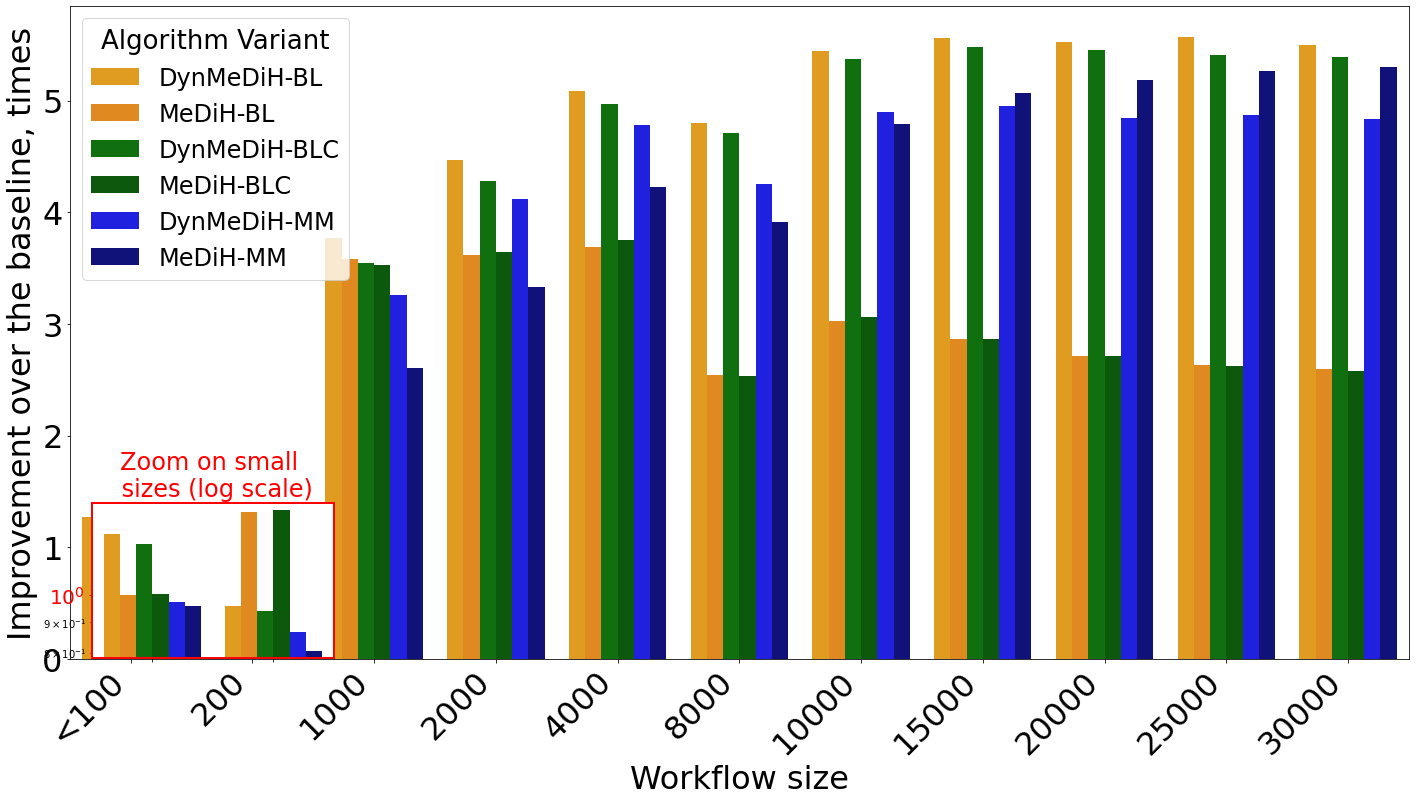

     size                   alg_rel     ratio
0     100    MeDiH-BL - dyn_vs_base  1.266315
1     100   MeDiH-BL - stat_vs_base  1.000000
2     100   MeDiH-BLC - dyn_vs_base  1.219631
3     100  MeDiH-BLC - stat_vs_base  1.004423
4     100    MeDiH-MM - dyn_vs_base  0.974285
..    ...                       ...       ...
61  30000   MeDiH-BL - stat_vs_base  2.592988
62  30000   MeDiH-BLC - dyn_vs_base  5.394761
63  30000  MeDiH-BLC - stat_vs_base  2.574718
64  30000    MeDiH-MM - dyn_vs_base  4.837365
65  30000   MeDiH-MM - stat_vs_base  5.298267

[66 rows x 3 columns]
alg_rel
MeDiH-BL - dyn_vs_base      3.823303
MeDiH-BL - stat_vs_base     2.527801
MeDiH-BLC - dyn_vs_base     3.723626
MeDiH-BLC - stat_vs_base    2.532068
MeDiH-MM - dyn_vs_base      3.370336
MeDiH-MM - stat_vs_base     3.222517
Name: ratio, dtype: float64


NameError: name 'size_order' is not defined

In [2]:

###############################################################################################
######This is checking Ruben's variant ########################################
##############################################################################################
#path = "./ruben-werte/final-kinda/merged/*.txt"
path = "./results/merged/*.txt"
print(path)

patterndevs = r'^(BASE|A\d+)-(ndev)'

dfs=read_dfs(path,patterndevs, 2)

dfsVar1 = [dfs[('A1','ndev')], dfs[('A2','ndev')], dfs[('A3','ndev')], dfs[('BASE','ndev')]]
#print(dfsVar1)
merged_df_var1 = merge_correct_columns(dfsVar1, labels)
#print(merged_df_var1)
plot_df = buld_plot_df(merged_df_var1)
plot_df = plot_df[plot_df["size"]!= 18000]

#print(plot_df[
#    (plot_df['relation'] == 'internal') &
#    (plot_df['algorithm'] == 'MeDiH-BL') 
#   # & (~plot_df['wf_name'].str.contains('eager')) 
#   & (plot_df['ratio'] > 1.5)
#].to_string())

plotDynAndStaticVsBase(plot_df, "no deviations", "Makespan improvement over baseline, ", ['stat_vs_base', 'dyn_vs_base'])#

allInternals = plot_df[plot_df['relation']=='internal']
allInternals = allInternals.copy()
#print(allInternals.to_string())
# Add a new column for size group
allInternals['size_group'] = allInternals['size'].apply(size_category)
# Filter only valid categories
filtered = allInternals[allInternals['size_group'] != 'other']
# Group by algorithm and size_group, then compute geometric mean
result = filtered.groupby(['algorithm', 'size_group'])['ratio'].agg(gmean).reset_index()

# Optionally, sort the result

result['size_group'] = pd.Categorical(result['size_group'], categories=size_order, ordered=True)
result = result.sort_values(['algorithm', 'size_group'])

print(result)

result2 = filtered.groupby(['algorithm', 'size'])['ratio'].agg(gmean).reset_index()
print("!!!", result2)

by_algo = allInternals.groupby('algorithm')['ratio'].agg(gmean).reset_index()
print(by_algo)

./ruben-werte/final-kinda/merged/*.txt
No match found. A1-ndev.txt
No match found. A2-ndev.txt
No match found. A3-ndev.txt
No match found. BASE-ndev.txt
     size          wf_name     inp_size  relation     ratio algorithm
9     200  chipseq_200.dot   5058052541  internal  1.633115  MeDiH-BL
32    200  atacseq_200.dot  11809629756  internal  3.151978  MeDiH-BL
43    200  chipseq_200.dot   3793245764  internal  1.951232  MeDiH-BL
74    200    eager_200.dot  25705994498  internal  1.566080  MeDiH-BL
112   200  atacseq_200.dot  14091675276  internal  3.526360  MeDiH-BL
129   200  atacseq_200.dot   3908761308  internal  2.685832  MeDiH-BL
131   200  atacseq_200.dot   2223941232  internal  2.732300  MeDiH-BL
162   200    eager_200.dot  19100037384  internal  1.758231  MeDiH-BL
177   200  atacseq_200.dot  11187378708  internal  4.945684  MeDiH-BL
197   200    eager_200.dot  19075314980  internal  1.679395  MeDiH-BL
223   200    eager_200.dot  19132169434  internal  1.755050  MeDiH-BL


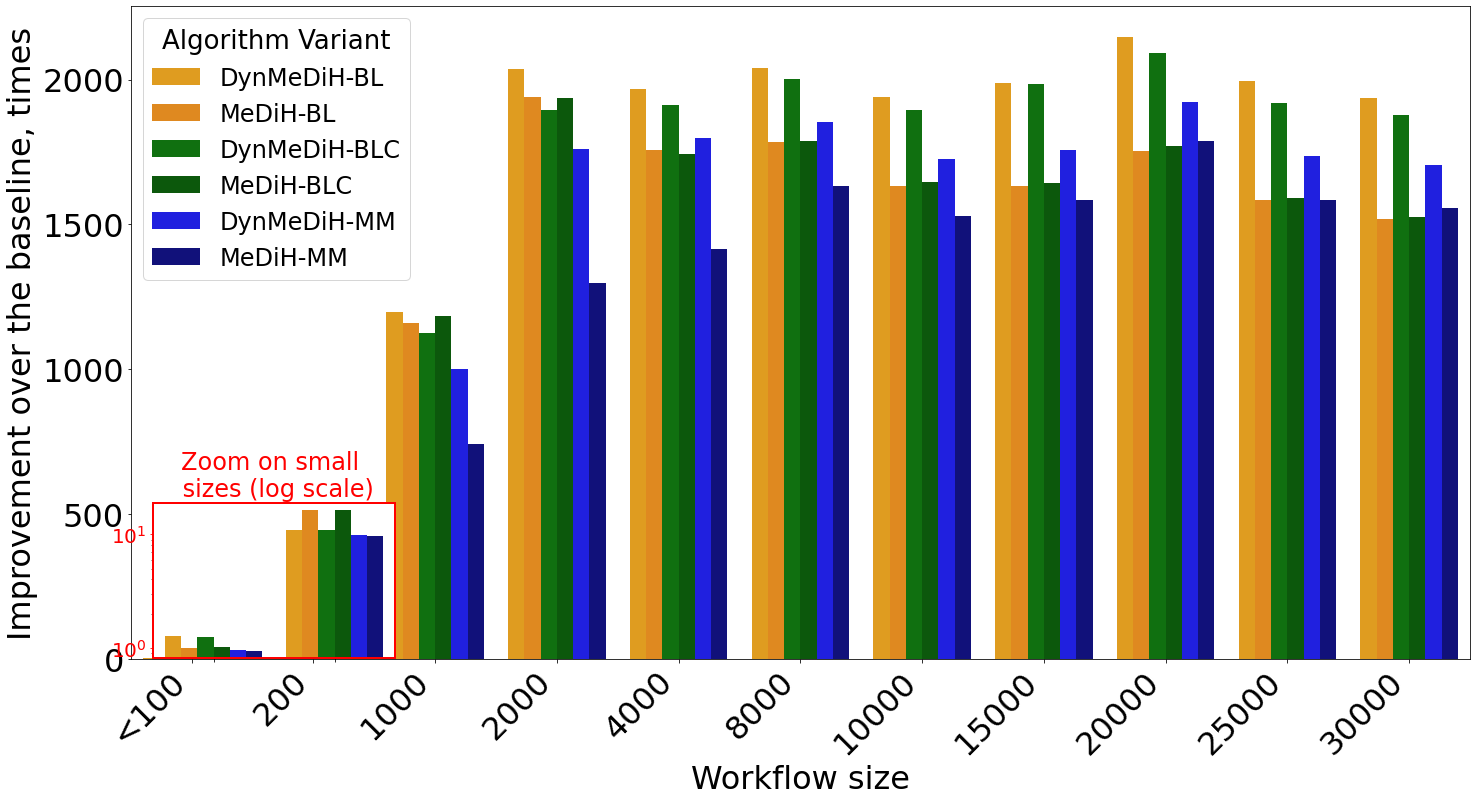

     size                   alg_rel        ratio
0     100    MeDiH-BL - dyn_vs_base     1.265963
1     100   MeDiH-BL - stat_vs_base     0.992516
2     100   MeDiH-BLC - dyn_vs_base     1.246759
3     100  MeDiH-BLC - stat_vs_base     1.009197
4     100    MeDiH-MM - dyn_vs_base     0.945182
..    ...                       ...          ...
61  30000   MeDiH-BL - stat_vs_base  1519.612852
62  30000   MeDiH-BLC - dyn_vs_base  1879.002966
63  30000  MeDiH-BLC - stat_vs_base  1524.097966
64  30000    MeDiH-MM - dyn_vs_base  1704.626049
65  30000   MeDiH-MM - stat_vs_base  1555.238253

[66 rows x 3 columns]
alg_rel
MeDiH-BL - dyn_vs_base      609.414061
MeDiH-BL - stat_vs_base     546.815060
MeDiH-BLC - dyn_vs_base     592.706935
MeDiH-BLC - stat_vs_base    549.660307
MeDiH-MM - dyn_vs_base      531.376177
MeDiH-MM - stat_vs_base     463.738176
Name: ratio, dtype: float64
    algorithm size_group     ratio
3    MeDiH-BL      small  1.157520
2    MeDiH-BL     middle  0.921220
0    MeDiH-BL 

In [8]:

###############################################################################################
######This is checking Ruben's variant ########################################
##############################################################################################
path = "./ruben-werte/final-kinda/merged/*.txt"
print(path)

patterndevs = r'^(BASE|A\d+)-(\d\ddev)'

dfs=read_dfs(path,patterndevs, 2)

dfsVar1 = [dfs[('A1','10dev')], dfs[('A2','10dev')], dfs[('A3','10dev')], dfs[('BASE','10dev')]]
#print(dfsVar1)
merged_df_var1 = merge_correct_columns(dfsVar1, labels)
#print(merged_df_var1)
plot_df = buld_plot_df(merged_df_var1)
plot_df = plot_df[plot_df["size"]!= 18000]

print(plot_df[
    (plot_df['relation'] == 'internal') &
    (plot_df['algorithm'] == 'MeDiH-BL') 
   # & (~plot_df['wf_name'].str.contains('eager')) 
   & (plot_df['ratio'] > 1.5)
].to_string())

plotDynAndStaticVsBase(plot_df, "small deviations", "Makespan improvement over baseline, ", ['stat_vs_base', 'dyn_vs_base'])#

allInternals = plot_df[plot_df['relation']=='internal']
allInternals = allInternals.copy()
#print(allInternals.to_string())
# Add a new column for size group
allInternals['size_group'] = allInternals['size'].apply(size_category)
# Filter only valid categories
filtered = allInternals[allInternals['size_group'] != 'other']
# Group by algorithm and size_group, then compute geometric mean
result = filtered.groupby(['algorithm', 'size_group'])['ratio'].agg(gmean).reset_index()

# Optionally, sort the result

result['size_group'] = pd.Categorical(result['size_group'], categories=size_order, ordered=True)
result = result.sort_values(['algorithm', 'size_group'])

print(result)

result2 = filtered.groupby(['algorithm', 'size'])['ratio'].agg(gmean).reset_index()
print("!!!", result2)

by_algo = allInternals.groupby('algorithm')['ratio'].agg(gmean).reset_index()
print(by_algo)

./ruben-werte/final-kinda/merged/*.txt
No match found. A1-ndev.txt
No match found. A2-ndev.txt
No match found. A3-ndev.txt
No match found. BASE-ndev.txt
     size          wf_name     inp_size  relation     ratio algorithm
9     200  chipseq_200.dot   5058052541  internal  1.559792  MeDiH-BL
32    200  atacseq_200.dot  11809629756  internal  4.721600  MeDiH-BL
43    200  chipseq_200.dot   3793245764  internal  2.175433  MeDiH-BL
111   200  atacseq_200.dot  14091675276  internal  2.620356  MeDiH-BL
128   200  atacseq_200.dot   3908761308  internal  2.427371  MeDiH-BL
130   200  atacseq_200.dot   2223941232  internal  2.560404  MeDiH-BL
160   200    eager_200.dot  19100037384  internal  1.756270  MeDiH-BL
175   200  atacseq_200.dot  11187378708  internal  2.769368  MeDiH-BL
195   200    eager_200.dot  19075314980  internal  1.747268  MeDiH-BL


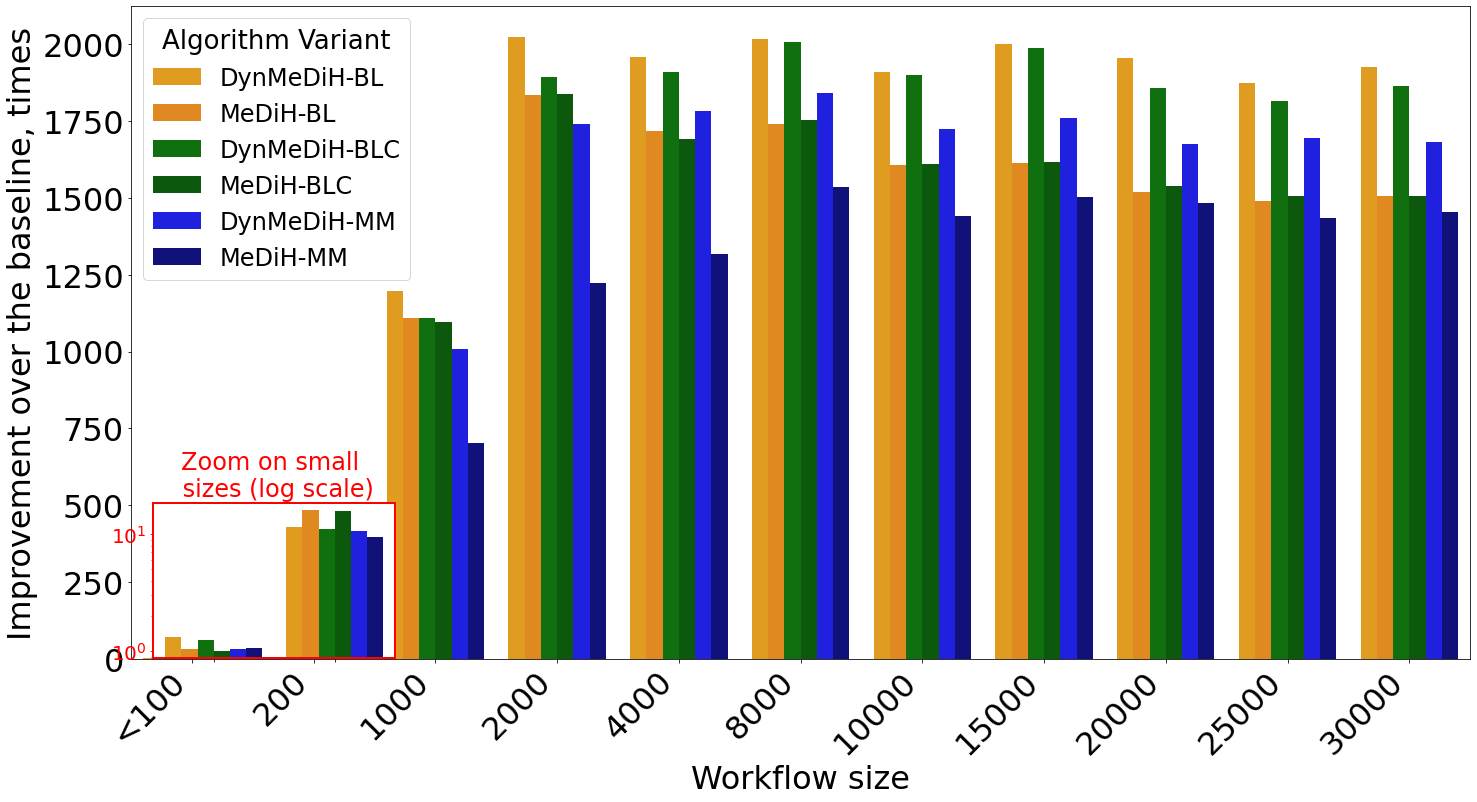

     size                   alg_rel        ratio
0     100    MeDiH-BL - dyn_vs_base     1.313214
1     100   MeDiH-BL - stat_vs_base     1.033998
2     100   MeDiH-BLC - dyn_vs_base     1.234626
3     100  MeDiH-BLC - stat_vs_base     1.003690
4     100    MeDiH-MM - dyn_vs_base     1.035688
..    ...                       ...          ...
61  30000   MeDiH-BL - stat_vs_base  1506.723484
62  30000   MeDiH-BLC - dyn_vs_base  1865.275883
63  30000  MeDiH-BLC - stat_vs_base  1506.687877
64  30000    MeDiH-MM - dyn_vs_base  1682.743548
65  30000   MeDiH-MM - stat_vs_base  1453.781369

[66 rows x 3 columns]
alg_rel
MeDiH-BL - dyn_vs_base      603.900472
MeDiH-BL - stat_vs_base     528.812662
MeDiH-BLC - dyn_vs_base     582.594709
MeDiH-BLC - stat_vs_base    526.967787
MeDiH-MM - dyn_vs_base      530.332280
MeDiH-MM - stat_vs_base     439.092378
Name: ratio, dtype: float64
    algorithm size_group     ratio
3    MeDiH-BL      small  1.110524
2    MeDiH-BL     middle  0.892269
0    MeDiH-BL 

In [9]:
###############################################################################################
######This is checking Ruben's variant ########################################
##############################################################################################
path = "./ruben-werte/final-kinda/merged/*.txt"
print(path)

patterndevs = r'^(BASE|A\d+)-(\d\ddev)'

dfs=read_dfs(path,patterndevs, 2)

dfsVar1 = [dfs[('A1','30dev')], dfs[('A2','30dev')], dfs[('A3','30dev')], dfs[('BASE','30dev')]]
#print(dfsVar1)
merged_df_var1 = merge_correct_columns(dfsVar1, labels)
#print(merged_df_var1)
plot_df = buld_plot_df(merged_df_var1)
plot_df = plot_df[plot_df["size"]!= 18000]

print(plot_df[
    (plot_df['relation'] == 'internal') &
    (plot_df['algorithm'] == 'MeDiH-BL') 
   # & (~plot_df['wf_name'].str.contains('eager')) 
   & (plot_df['ratio'] > 1.5)
].to_string())

plotDynAndStaticVsBase(plot_df, "mid deviations", "Makespan improvement over baseline, ", ['stat_vs_base', 'dyn_vs_base'])#

allInternals = plot_df[plot_df['relation']=='internal']
allInternals = allInternals.copy()
#print(allInternals.to_string())
# Add a new column for size group
allInternals['size_group'] = allInternals['size'].apply(size_category)
# Filter only valid categories
filtered = allInternals[allInternals['size_group'] != 'other']
# Group by algorithm and size_group, then compute geometric mean
result = filtered.groupby(['algorithm', 'size_group'])['ratio'].agg(gmean).reset_index()

# Optionally, sort the result

result['size_group'] = pd.Categorical(result['size_group'], categories=size_order, ordered=True)
result = result.sort_values(['algorithm', 'size_group'])

print(result)

result2 = filtered.groupby(['algorithm', 'size'])['ratio'].agg(gmean).reset_index()
print("!!!", result2)

by_algo = allInternals.groupby('algorithm')['ratio'].agg(gmean).reset_index()
print(by_algo)

./ruben-werte/final-kinda/merged/*.txt
No match found. A1-ndev.txt
No match found. A2-ndev.txt
No match found. A3-ndev.txt
No match found. BASE-ndev.txt
     size          wf_name     inp_size  relation     ratio algorithm
32    200  atacseq_200.dot  11809629756  internal  2.630761  MeDiH-BL
43    200  chipseq_200.dot   3793245764  internal  1.520585  MeDiH-BL
112   200  atacseq_200.dot  14091675276  internal  3.048197  MeDiH-BL
128   200  atacseq_200.dot   3908761308  internal  2.124870  MeDiH-BL
130   200  atacseq_200.dot   2223941232  internal  2.158445  MeDiH-BL
161   200    eager_200.dot  19100037384  internal  1.586282  MeDiH-BL
176   200  atacseq_200.dot  11187378708  internal  2.624417  MeDiH-BL
196   200    eager_200.dot  19075314980  internal  1.689736  MeDiH-BL
222   200    eager_200.dot  19132169434  internal  1.592495  MeDiH-BL


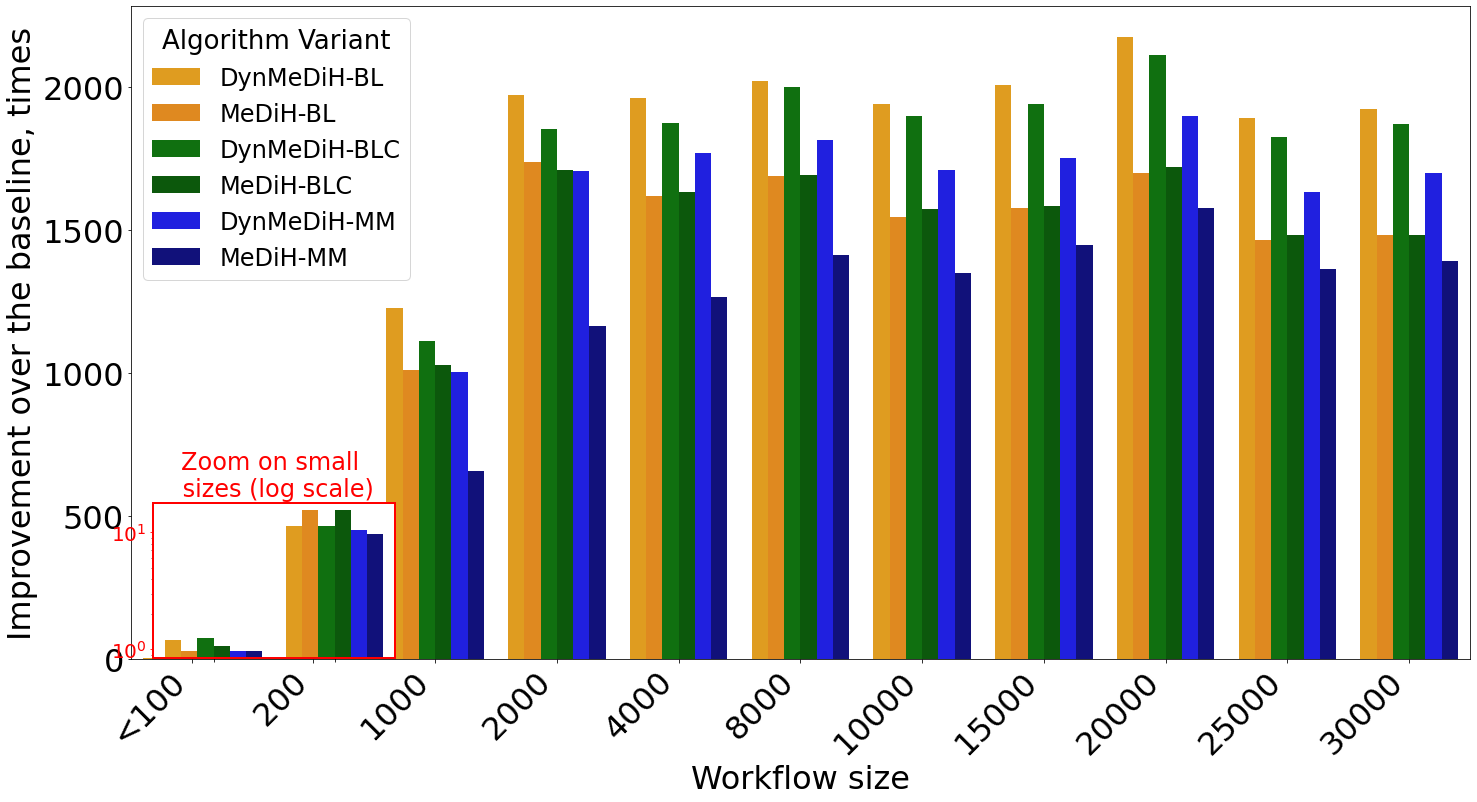

     size                   alg_rel        ratio
0     100    MeDiH-BL - dyn_vs_base     1.194696
1     100   MeDiH-BL - stat_vs_base     0.970116
2     100   MeDiH-BLC - dyn_vs_base     1.261468
3     100  MeDiH-BLC - stat_vs_base     1.062749
4     100    MeDiH-MM - dyn_vs_base     0.968973
..    ...                       ...          ...
61  30000   MeDiH-BL - stat_vs_base  1481.584155
62  30000   MeDiH-BLC - dyn_vs_base  1869.939764
63  30000  MeDiH-BLC - stat_vs_base  1483.321314
64  30000    MeDiH-MM - dyn_vs_base  1699.239624
65  30000   MeDiH-MM - stat_vs_base  1390.819655

[66 rows x 3 columns]
alg_rel
MeDiH-BL - dyn_vs_base      605.189264
MeDiH-BL - stat_vs_base     513.034502
MeDiH-BLC - dyn_vs_base     588.882444
MeDiH-BLC - stat_vs_base    520.502106
MeDiH-MM - dyn_vs_base      527.579579
MeDiH-MM - stat_vs_base     421.768373
Name: ratio, dtype: float64
    algorithm size_group     ratio
3    MeDiH-BL      small  1.104223
2    MeDiH-BL     middle  0.840430
0    MeDiH-BL 

In [10]:

###############################################################################################
######This is checking Ruben's variant ########################################
##############################################################################################
path = "./ruben-werte/final-kinda/merged/*.txt"
print(path)

patterndevs = r'^(BASE|A\d+)-(\d\ddev)'

dfs=read_dfs(path,patterndevs, 2)

dfsVar1 = [dfs[('A1','50dev')], dfs[('A2','50dev')], dfs[('A3','50dev')], dfs[('BASE','50dev')]]
#print(dfsVar1)
merged_df_var1 = merge_correct_columns(dfsVar1, labels)
#print(merged_df_var1)
plot_df = buld_plot_df(merged_df_var1)
plot_df = plot_df[plot_df["size"]!= 18000]

print(plot_df[
    (plot_df['relation'] == 'internal') &
    (plot_df['algorithm'] == 'MeDiH-BL') 
   # & (~plot_df['wf_name'].str.contains('eager')) 
   & (plot_df['ratio'] > 1.5)
].to_string())

plotDynAndStaticVsBase(plot_df, "big deviations", "Makespan improvement over baseline, ", ['stat_vs_base', 'dyn_vs_base'])#

allInternals = plot_df[plot_df['relation']=='internal']
allInternals = allInternals.copy()
#print(allInternals.to_string())
# Add a new column for size group
allInternals['size_group'] = allInternals['size'].apply(size_category)
# Filter only valid categories
filtered = allInternals[allInternals['size_group'] != 'other']
# Group by algorithm and size_group, then compute geometric mean
result = filtered.groupby(['algorithm', 'size_group'])['ratio'].agg(gmean).reset_index()

# Optionally, sort the result

result['size_group'] = pd.Categorical(result['size_group'], categories=size_order, ordered=True)
result = result.sort_values(['algorithm', 'size_group'])

print(result)

result2 = filtered.groupby(['algorithm', 'size'])['ratio'].agg(gmean).reset_index()
print("!!!", result2)

by_algo = allInternals.groupby('algorithm')['ratio'].agg(gmean).reset_index()
print(by_algo)

In [4]:


def plotDynAndStaticVsBaseNoInset(our_df, deviationsText, titleText, relations):
   
    filtered_df = our_df[our_df['relation'].isin(relations)].copy()# ['internal']
    filtered_df['alg_rel'] = filtered_df['algorithm'] + ' - ' + filtered_df['relation']
    #print("filtered_df\n", filtered_df)

    fig, ax = plt.subplots(figsize=(24, 12))
    ax = sns.barplot(
        data=filtered_df,
        x='size',
        y='ratio',
        hue='alg_rel',
        estimator=gmean,
        palette=palette,
        ci=None
    )
    if "internal" in relations:
        baseline_line = plt.axhline(y=1, color='red', linestyle='--', linewidth=1.5, label='Equal')    
    plt.xticks(rotation=45)
  
    plt.yticks(fontsize=32)
    plt.xticks(fontsize=32)
    plt.xlabel('Workflow size', fontsize=32)
    plt.ylabel('Improvement over the baseline, times', fontsize=32)
    plt.legend(fontsize=32, title_fontsize=32)  


    
    xticks = ax.get_xticks()
    xticklabels = [tick.get_text() for tick in ax.get_xticklabels()]

    # Replace label "100" with "<100"
    new_labels = ["<100" if lbl == "100" else lbl for lbl in xticklabels]

    # Apply the modified labels
    ax.set_xticklabels(new_labels, fontsize=32, rotation=45, ha='right')

    handles, labels = ax.get_legend_handles_labels()

    # Apply the mapping
    pretty_labels = [label_map.get(lbl, lbl) for lbl in labels]

    
    # Set updated legend
    ax.legend(handles, pretty_labels, title="Algorithm Variant", fontsize=24, title_fontsize=26)
   # plt.title(f'{titleText} {deviationsText}', fontsize=28) #Makespan improvement over the baseline,

  
    plt.savefig(f'improv_ov_baseline_newest_{deviationsText}.png', facecolor='white',  bbox_inches='tight')
    plt.show()

    grouped = filtered_df.groupby(['size', 'alg_rel'])['ratio'].agg(safe_gmean).reset_index()
    # Print the values used for bar heights
    print(grouped)

    gr = grouped.groupby(['alg_rel'])['ratio'].agg(safe_gmean)
    print(gr)

./results-3-12/merged/*.txt
No match found. BASE-50dev.txt
No match found. A1-50dev.txt
No match found. A2-50dev.txt
No match found. BASE-30dev.txt
No match found. A2-10dev.txt
No match found. A1-30dev.txt
No match found. A3-30dev.txt
No match found. BASE-10dev.txt
No match found. A2-30dev.txt
No match found. A3-50dev.txt
No match found. A3-10dev.txt
No match found. A1-10dev.txt
[                 wf_name     inp_size       ms_1_A1       ms_2_A1
0      atacseq_30000.dot  14091675276  1.421259e+09  1.583728e+09
1      chipseq_15000.dot  41366257414  3.256855e+09  7.547922e+09
2    methylseq_15000.dot   6761426956  1.221635e+08  4.752229e+08
3      atacseq_15000.dot   3908761308  2.049557e+08  1.629076e+08
4         eager_1000.dot  25705994498  4.168264e+07  2.253165e+07
..                   ...          ...           ...           ...
245    chipseq_30000.dot   3793245764  6.285083e+08  6.327128e+08
246   methylseq_1000.dot   8885797810  1.126641e+07  1.385122e+07
247  methylseq_10000.do

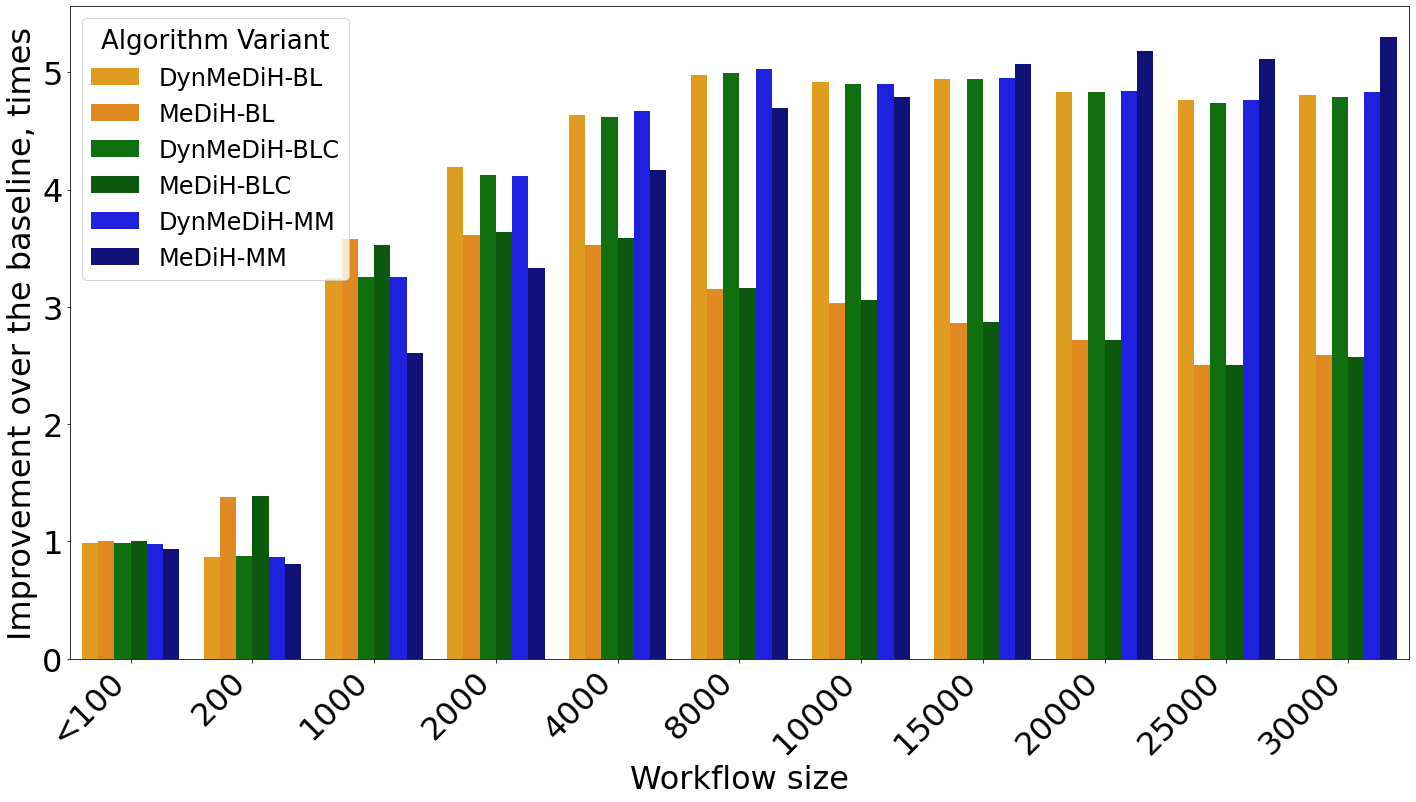

     size                   alg_rel     ratio
0     100    MeDiH-BL - dyn_vs_base  0.988959
1     100   MeDiH-BL - stat_vs_base  1.000000
2     100   MeDiH-BLC - dyn_vs_base  0.988959
3     100  MeDiH-BLC - stat_vs_base  1.006844
4     100    MeDiH-MM - dyn_vs_base  0.976487
..    ...                       ...       ...
61  30000   MeDiH-BL - stat_vs_base  2.592988
62  30000   MeDiH-BLC - dyn_vs_base  4.790581
63  30000  MeDiH-BLC - stat_vs_base  2.574718
64  30000    MeDiH-MM - dyn_vs_base  4.837365
65  30000   MeDiH-MM - stat_vs_base  5.298267

[66 rows x 3 columns]
alg_rel
MeDiH-BL - dyn_vs_base      3.412785
MeDiH-BL - stat_vs_base     2.556083
MeDiH-BLC - dyn_vs_base     3.406148
MeDiH-BLC - stat_vs_base    2.562611
MeDiH-MM - dyn_vs_base      3.407657
MeDiH-MM - stat_vs_base     3.256870
Name: ratio, dtype: float64
   algorithm size_group     ratio
0   MeDiH-BL        NaN  0.542495
1   MeDiH-BL        NaN  0.609158
2   MeDiH-BL        NaN  1.031303
3  MeDiH-BLC        NaN  0.5426

In [13]:

#//////////////// newest results 3/12/25 with new formula //////////////////////////
#///////////////NO DEVIATIONS////////////////////////////////
path = "./results-3-12/merged/*.txt"
print(path)

patterndevs = r'^(BASE|A\d+)-(ndev)'

dfs=read_dfs(path,patterndevs, 2)


dfsVar1 = [dfs[('A1','ndev')], dfs[('A2','ndev')], dfs[('A3','ndev')], dfs[('BASE','ndev')]]
#print(dfsVar1)
merged_df_var1 = merge_correct_columns(dfsVar1, labels)
#print(merged_df_var1)
plot_df = buld_plot_df(merged_df_var1)
plot_df = plot_df[plot_df["size"]!= 18000]

#print(plot_df)
#print(plot_df[
#    (plot_df['relation'] == 'internal') &
#    (plot_df['algorithm'] == 'MeDiH-BL') 
#   # & (~plot_df['wf_name'].str.contains('eager')) 
#   & (plot_df['ratio'] > 1.5)
#].to_string())



plotDynAndStaticVsBaseNoInset(plot_df, "no deviations", "Makespan improvement over baseline, ", ['stat_vs_base', 'dyn_vs_base'])#

allInternals = plot_df[plot_df['relation']=='internal']
allInternals = allInternals.copy()
#print(allInternals.to_string())
# Add a new column for size group
allInternals['size_group'] = allInternals['size'].apply(size_category)
# Filter only valid categories
filtered = allInternals[allInternals['size_group'] != 'other']
# Group by algorithm and size_group, then compute geometric mean
result = filtered.groupby(['algorithm', 'size_group'])['ratio'].agg(gmean).reset_index()

# Optionally, sort the result

result['size_group'] = pd.Categorical(result['size_group'], categories=size_order, ordered=True)
result = result.sort_values(['algorithm', 'size_group'])

print(result)

result2 = filtered.groupby(['algorithm', 'size'])['ratio'].agg(gmean).reset_index()
print("!!!", result2)

by_algo = allInternals.groupby('algorithm')['ratio'].agg(gmean).reset_index()
print(by_algo)

./results-3-12/merged/*.txt
No match found. A1-ndev.txt
No match found. A2-ndev.txt
No match found. A3-ndev.txt
No match found. BASE-ndev.txt
[                 wf_name     inp_size       ms_1_A1       ms_2_A1
0      atacseq_30000.dot  14091675276  1.452748e+09  1.589795e+09
1      chipseq_15000.dot  41366257414  3.290944e+09  7.661549e+09
2    methylseq_15000.dot   6761426956  1.229063e+08  5.162945e+08
3      atacseq_15000.dot   3908761308  2.075573e+08  1.636468e+08
4         eager_1000.dot  25705994498  4.057745e+07  2.425258e+07
..                   ...          ...           ...           ...
246    chipseq_30000.dot   3793245764  6.381071e+08  6.307113e+08
247   methylseq_1000.dot   8885797810  1.124268e+07  1.378817e+07
248  methylseq_10000.dot  17027257018  3.132333e+08  1.458594e+09
249        eager_200.dot   8330435694  7.687601e+06  3.281986e+06
250    chipseq_10000.dot   4807293396  1.675461e+08  1.720678e+08

[251 rows x 4 columns],                  wf_name     inp_size   

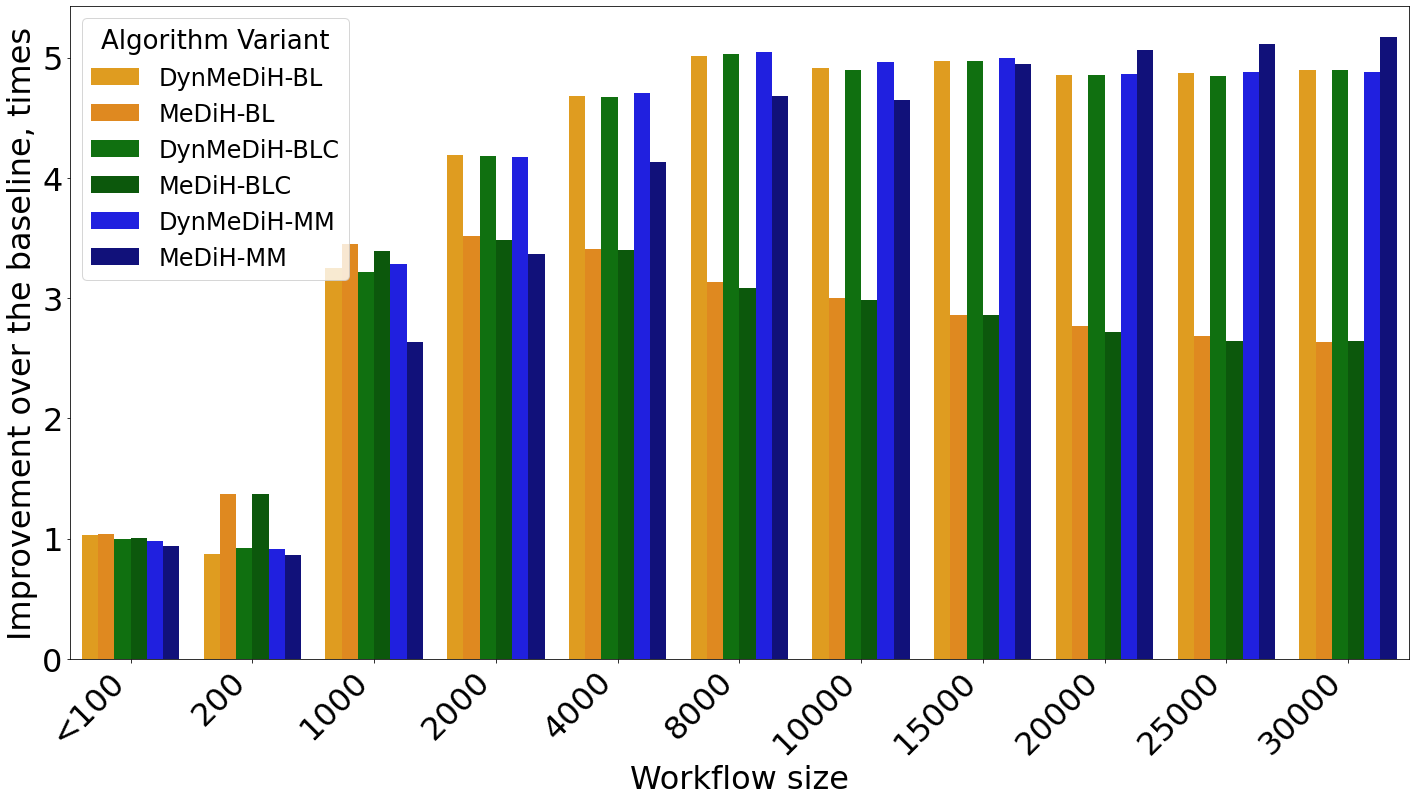

     size                   alg_rel     ratio
0     100    MeDiH-BL - dyn_vs_base  1.030554
1     100   MeDiH-BL - stat_vs_base  1.034684
2     100   MeDiH-BLC - dyn_vs_base  0.998714
3     100  MeDiH-BLC - stat_vs_base  1.006383
4     100    MeDiH-MM - dyn_vs_base  0.979305
..    ...                       ...       ...
61  30000   MeDiH-BL - stat_vs_base  2.630331
62  30000   MeDiH-BLC - dyn_vs_base  4.896026
63  30000  MeDiH-BLC - stat_vs_base  2.639608
64  30000    MeDiH-MM - dyn_vs_base  4.882952
65  30000   MeDiH-MM - stat_vs_base  5.166724

[66 rows x 3 columns]
alg_rel
MeDiH-BL - dyn_vs_base      3.445775
MeDiH-BL - stat_vs_base     2.559248
MeDiH-BLC - dyn_vs_base     3.446594
MeDiH-BLC - stat_vs_base    2.533778
MeDiH-MM - dyn_vs_base      3.452150
MeDiH-MM - stat_vs_base     3.250669
Name: ratio, dtype: float64
   algorithm size_group     ratio
0   MeDiH-BL        NaN  0.552448
1   MeDiH-BL        NaN  0.603194
2   MeDiH-BL        NaN  1.005122
3  MeDiH-BLC        NaN  0.5480

In [10]:

#//////////////// newest results 3/12/25 with new formula //////////////////////////
#///////////////SMALL 10% DEVIATIONS////////////////////////////////
path = "./results-3-12/merged/*.txt"
print(path)

patterndevs = r'^(BASE|A\d+)-(\d\ddev)'

dfs=read_dfs(path,patterndevs, 2)


dfsVar1 = [dfs[('A1','10dev')], dfs[('A2','10dev')], dfs[('A3','10dev')], dfs[('BASE','10dev')]]
#print(dfsVar1)
merged_df_var1 = merge_correct_columns(dfsVar1, labels)
#print(merged_df_var1)
plot_df = buld_plot_df(merged_df_var1)
plot_df = plot_df[plot_df["size"]!= 18000]

#print(plot_df)
#print(plot_df[
#    (plot_df['relation'] == 'internal') &
#    (plot_df['algorithm'] == 'MeDiH-BL') 
#   # & (~plot_df['wf_name'].str.contains('eager')) 
#   & (plot_df['ratio'] > 1.5)
#].to_string())



plotDynAndStaticVsBaseNoInset(plot_df, "moderate deviations", "Makespan improvement over baseline, ", ['stat_vs_base', 'dyn_vs_base'])#

allInternals = plot_df[plot_df['relation']=='internal']
allInternals = allInternals.copy()
#print(allInternals.to_string())
# Add a new column for size group
allInternals['size_group'] = allInternals['size'].apply(size_category)
# Filter only valid categories
filtered = allInternals[allInternals['size_group'] != 'other']
# Group by algorithm and size_group, then compute geometric mean
result = filtered.groupby(['algorithm', 'size_group'])['ratio'].agg(gmean).reset_index()

# Optionally, sort the result

result['size_group'] = pd.Categorical(result['size_group'], categories=size_order, ordered=True)
result = result.sort_values(['algorithm', 'size_group'])

print(result)

result2 = filtered.groupby(['algorithm', 'size'])['ratio'].agg(gmean).reset_index()
print("!!!", result2)

by_algo = allInternals.groupby('algorithm')['ratio'].agg(gmean).reset_index()
print(by_algo)

./results-3-12/merged/*.txt
No match found. A1-ndev.txt
No match found. A2-ndev.txt
No match found. A3-ndev.txt
No match found. BASE-ndev.txt
[                 wf_name     inp_size       ms_1_A1       ms_2_A1
0      atacseq_30000.dot  14091675276  1.451173e+09  1.781249e+09
1      chipseq_15000.dot  41366257414  3.279929e+09  1.027495e+10
2    methylseq_15000.dot   6761426956  1.227801e+08  8.648523e+08
3      atacseq_15000.dot   3908761308  2.035238e+08  1.862507e+08
4         eager_1000.dot  25705994498  4.648442e+07  2.742495e+07
..                   ...          ...           ...           ...
246    chipseq_30000.dot   3793245764  6.494822e+08  6.949038e+08
247   methylseq_1000.dot   8885797810  1.533698e+07  2.093524e+07
248  methylseq_10000.dot  17027257018  3.121507e+08  2.238314e+09
249        eager_200.dot   8330435694  7.839644e+06  4.722195e+06
250    chipseq_10000.dot   4807293396  1.656220e+08  1.799526e+08

[251 rows x 4 columns],                  wf_name     inp_size   

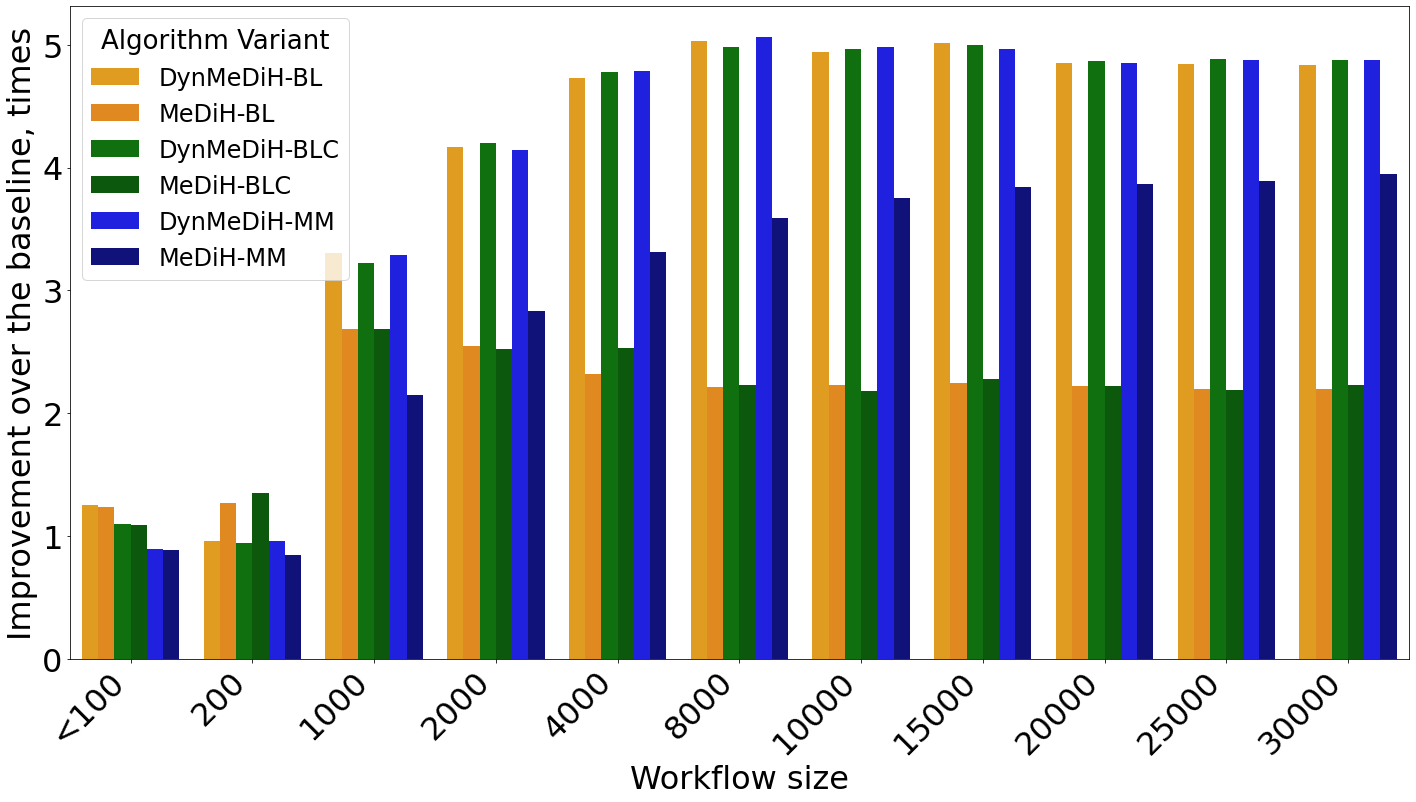

     size                   alg_rel     ratio
0     100    MeDiH-BL - dyn_vs_base  1.254706
1     100   MeDiH-BL - stat_vs_base  1.236623
2     100   MeDiH-BLC - dyn_vs_base  1.100625
3     100  MeDiH-BLC - stat_vs_base  1.091026
4     100    MeDiH-MM - dyn_vs_base  0.897511
..    ...                       ...       ...
61  30000   MeDiH-BL - stat_vs_base  2.195092
62  30000   MeDiH-BLC - dyn_vs_base  4.875812
63  30000  MeDiH-BLC - stat_vs_base  2.228957
64  30000    MeDiH-MM - dyn_vs_base  4.877684
65  30000   MeDiH-MM - stat_vs_base  3.945561

[66 rows x 3 columns]
alg_rel
MeDiH-BL - dyn_vs_base      3.546092
MeDiH-BL - stat_vs_base     2.068583
MeDiH-BLC - dyn_vs_base     3.500078
MeDiH-BLC - stat_vs_base    2.074025
MeDiH-MM - dyn_vs_base      3.447090
MeDiH-MM - stat_vs_base     2.657108
Name: ratio, dtype: float64
   algorithm size_group     ratio
0   MeDiH-BL        NaN  0.454796
1   MeDiH-BL        NaN  0.446489
2   MeDiH-BL        NaN  0.774687
3  MeDiH-BLC        NaN  0.4541

In [12]:

#//////////////// newest results 3/12/25 with new formula //////////////////////////
#///////////////SMALL 50% DEVIATIONS////////////////////////////////
path = "./results-3-12/merged/*.txt"
print(path)

patterndevs = r'^(BASE|A\d+)-(\d\ddev)'

dfs=read_dfs(path,patterndevs, 2)


dfsVar1 = [dfs[('A1','50dev')], dfs[('A2','50dev')], dfs[('A3','50dev')], dfs[('BASE','50dev')]]
#print(dfsVar1)
merged_df_var1 = merge_correct_columns(dfsVar1, labels)
#print(merged_df_var1)
plot_df = buld_plot_df(merged_df_var1)
plot_df = plot_df[plot_df["size"]!= 18000]

#print(plot_df)
#print(plot_df[
#    (plot_df['relation'] == 'internal') &
#    (plot_df['algorithm'] == 'MeDiH-BL') 
#   # & (~plot_df['wf_name'].str.contains('eager')) 
#   & (plot_df['ratio'] > 1.5)
#].to_string())



plotDynAndStaticVsBaseNoInset(plot_df, "largest deviations", "Makespan improvement over baseline, ", ['stat_vs_base', 'dyn_vs_base'])#

allInternals = plot_df[plot_df['relation']=='internal']
allInternals = allInternals.copy()
#print(allInternals.to_string())
# Add a new column for size group
allInternals['size_group'] = allInternals['size'].apply(size_category)
# Filter only valid categories
filtered = allInternals[allInternals['size_group'] != 'other']
# Group by algorithm and size_group, then compute geometric mean
result = filtered.groupby(['algorithm', 'size_group'])['ratio'].agg(gmean).reset_index()

# Optionally, sort the result

result['size_group'] = pd.Categorical(result['size_group'], categories=size_order, ordered=True)
result = result.sort_values(['algorithm', 'size_group'])

print(result)

result2 = filtered.groupby(['algorithm', 'size'])['ratio'].agg(gmean).reset_index()
print("!!!", result2)

by_algo = allInternals.groupby('algorithm')['ratio'].agg(gmean).reset_index()
print(by_algo)

./results-9-12/merged/*.txt
No match found. A3-bdev.txt
No match found. BASE-dev.txt
No match found. A2-dev.txt
No match found. BASE-30dev.txt
No match found. A3-dev.txt
No match found. A1-30dev.txt
No match found. A3-30dev.txt
No match found. A1-dev.txt
No match found. A2-bdev.txt
No match found. A2-30dev.txt
No match found. A1-bdev.txt
No match found. BASE-bdev.txt


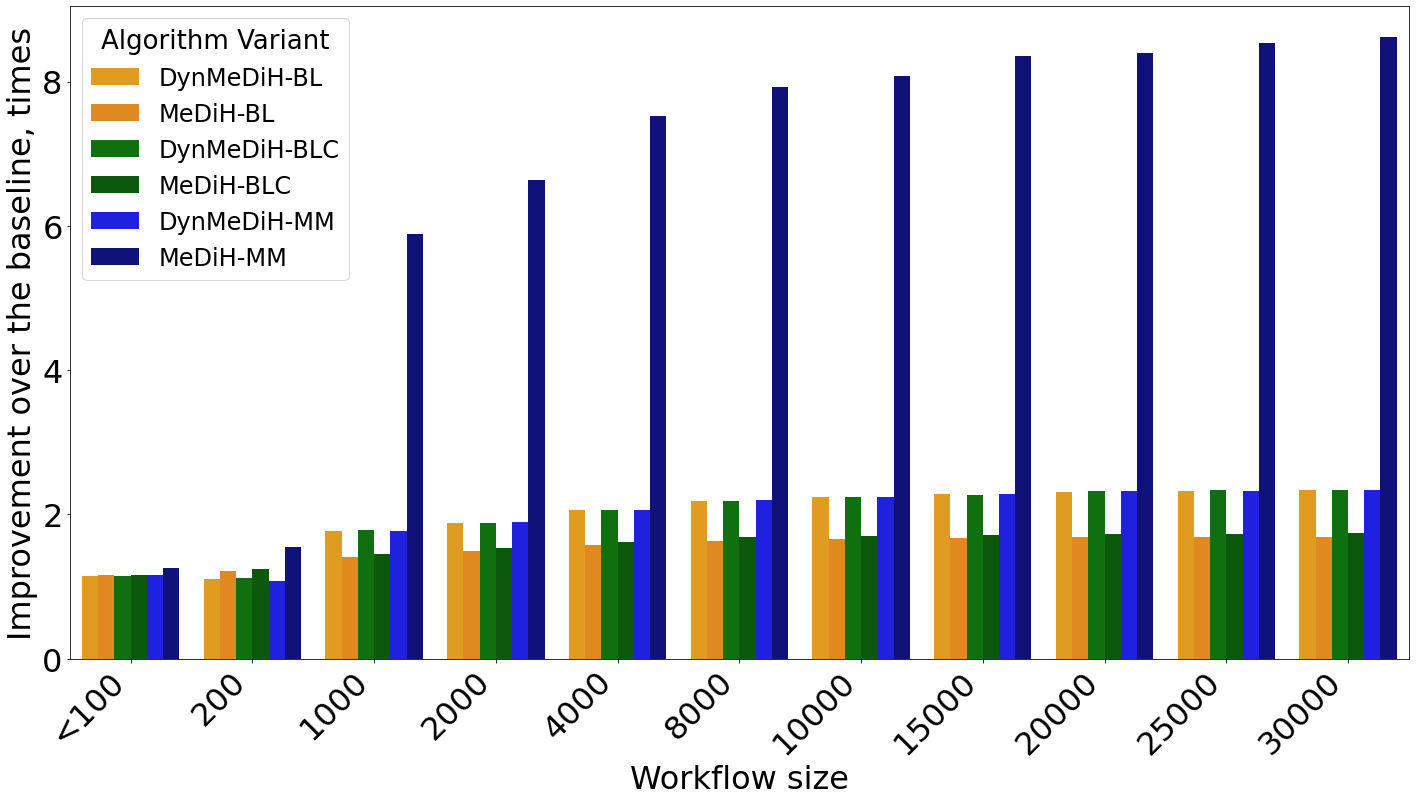

     size                   alg_rel     ratio
0     100    MeDiH-BL - dyn_vs_base  1.151947
1     100   MeDiH-BL - stat_vs_base  1.159627
2     100   MeDiH-BLC - dyn_vs_base  1.147093
3     100  MeDiH-BLC - stat_vs_base  1.159326
4     100    MeDiH-MM - dyn_vs_base  1.164328
..    ...                       ...       ...
61  30000   MeDiH-BL - stat_vs_base  1.692417
62  30000   MeDiH-BLC - dyn_vs_base  2.338323
63  30000  MeDiH-BLC - stat_vs_base  1.739328
64  30000    MeDiH-MM - dyn_vs_base  2.342864
65  30000   MeDiH-MM - stat_vs_base  8.610452

[66 rows x 3 columns]
alg_rel
MeDiH-BL - dyn_vs_base      1.907801
MeDiH-BL - stat_vs_base     1.522892
MeDiH-BLC - dyn_vs_base     1.911995
MeDiH-BLC - stat_vs_base    1.559583
MeDiH-MM - dyn_vs_base      1.911303
MeDiH-MM - stat_vs_base     5.650777
Name: ratio, dtype: float64
    algorithm size_group     ratio
3    MeDiH-BL      small  1.061677
2    MeDiH-BL     middle  0.775725
0    MeDiH-BL      large  0.735822
1    MeDiH-BL    largest  0

In [6]:
#//////////////// newest results 9/12/25 with new formula //////////////////////////
#///////////////NO DEVIATIONS////////////////////////////////
path = "./results-9-12/merged/*.txt"
print(path)

patterndevs = r'^(BASE|A\d+)-(ndev)'

dfs=read_dfs(path,patterndevs, 2)


dfsVar1 = [dfs[('A1','ndev')], dfs[('A2','ndev')], dfs[('A3','ndev')], dfs[('BASE','ndev')]]
#print(dfsVar1)
merged_df_var1 = merge_correct_columns(dfsVar1, labels)
#print(merged_df_var1)
plot_df = buld_plot_df(merged_df_var1)
plot_df = plot_df[plot_df["size"]!= 18000]

#print(plot_df)
#print(plot_df[
#    (plot_df['relation'] == 'internal') &
#    (plot_df['algorithm'] == 'MeDiH-BL') 
#   # & (~plot_df['wf_name'].str.contains('eager')) 
#   & (plot_df['ratio'] > 1.5)
#].to_string())



plotDynAndStaticVsBaseNoInset(plot_df, "no deviations", "Makespan improvement over baseline, ", ['stat_vs_base', 'dyn_vs_base'])#

allInternals = plot_df[plot_df['relation']=='internal']
allInternals = allInternals.copy()
#print(allInternals.to_string())
# Add a new column for size group
allInternals['size_group'] = allInternals['size'].apply(size_category)
# Filter only valid categories
filtered = allInternals[allInternals['size_group'] != 'other']
# Group by algorithm and size_group, then compute geometric mean
result = filtered.groupby(['algorithm', 'size_group'])['ratio'].agg(gmean).reset_index()

# Optionally, sort the result

result['size_group'] = pd.Categorical(result['size_group'], categories=size_order, ordered=True)
result = result.sort_values(['algorithm', 'size_group'])

print(result)

result2 = filtered.groupby(['algorithm', 'size'])['ratio'].agg(gmean).reset_index()
print("!!!", result2)

by_algo = allInternals.groupby('algorithm')['ratio'].agg(gmean).reset_index()
print(by_algo)

In [ ]:
#//////////////// newest results 9/12/25 with new formula //////////////////////////
#///////////////NO DEVIATIONS////////////////////////////////
path = "./results-9-12/merged/*.txt"
print(path)

patterndevs = r'^(BASE|A\d+)-(ndev)'

dfs=read_dfs(path,patterndevs, 2)


dfsVar1 = [dfs[('A1','ndev')], dfs[('A2','ndev')], dfs[('A3','ndev')], dfs[('BASE','ndev')]]
#print(dfsVar1)
merged_df_var1 = merge_correct_columns(dfsVar1, labels)
#print(merged_df_var1)
plot_df = buld_plot_df(merged_df_var1)
plot_df = plot_df[plot_df["size"]!= 18000]

#print(plot_df)
#print(plot_df[
#    (plot_df['relation'] == 'internal') &
#    (plot_df['algorithm'] == 'MeDiH-BL') 
#   # & (~plot_df['wf_name'].str.contains('eager')) 
#   & (plot_df['ratio'] > 1.5)
#].to_string())



plotDynAndStaticVsBaseNoInset(plot_df, "no deviations", "Makespan improvement over baseline, ", ['stat_vs_base', 'dyn_vs_base'])#

allInternals = plot_df[plot_df['relation']=='internal']
allInternals = allInternals.copy()
#print(allInternals.to_string())
# Add a new column for size group
allInternals['size_group'] = allInternals['size'].apply(size_category)
# Filter only valid categories
filtered = allInternals[allInternals['size_group'] != 'other']
# Group by algorithm and size_group, then compute geometric mean
result = filtered.groupby(['algorithm', 'size_group'])['ratio'].agg(gmean).reset_index()

# Optionally, sort the result

result['size_group'] = pd.Categorical(result['size_group'], categories=size_order, ordered=True)
result = result.sort_values(['algorithm', 'size_group'])

print(result)

result2 = filtered.groupby(['algorithm', 'size'])['ratio'].agg(gmean).reset_index()
print("!!!", result2)

by_algo = allInternals.groupby('algorithm')['ratio'].agg(gmean).reset_index()
print(by_algo)

./results-11-12/merged/*.txt
No match found. BASE-50dev.txt
No match found. BASE-dev.txt
No match found. A2-dev.txt
No match found. A1-50dev.txt
No match found. A2-50dev.txt
No match found. BASE-30dev.txt
No match found. A3-dev.txt
No match found. A1-30dev.txt
No match found. A3-30dev.txt
No match found. A2-30dev.txt
No match found. A3-50dev.txt
No match found. A1-10dev.txt


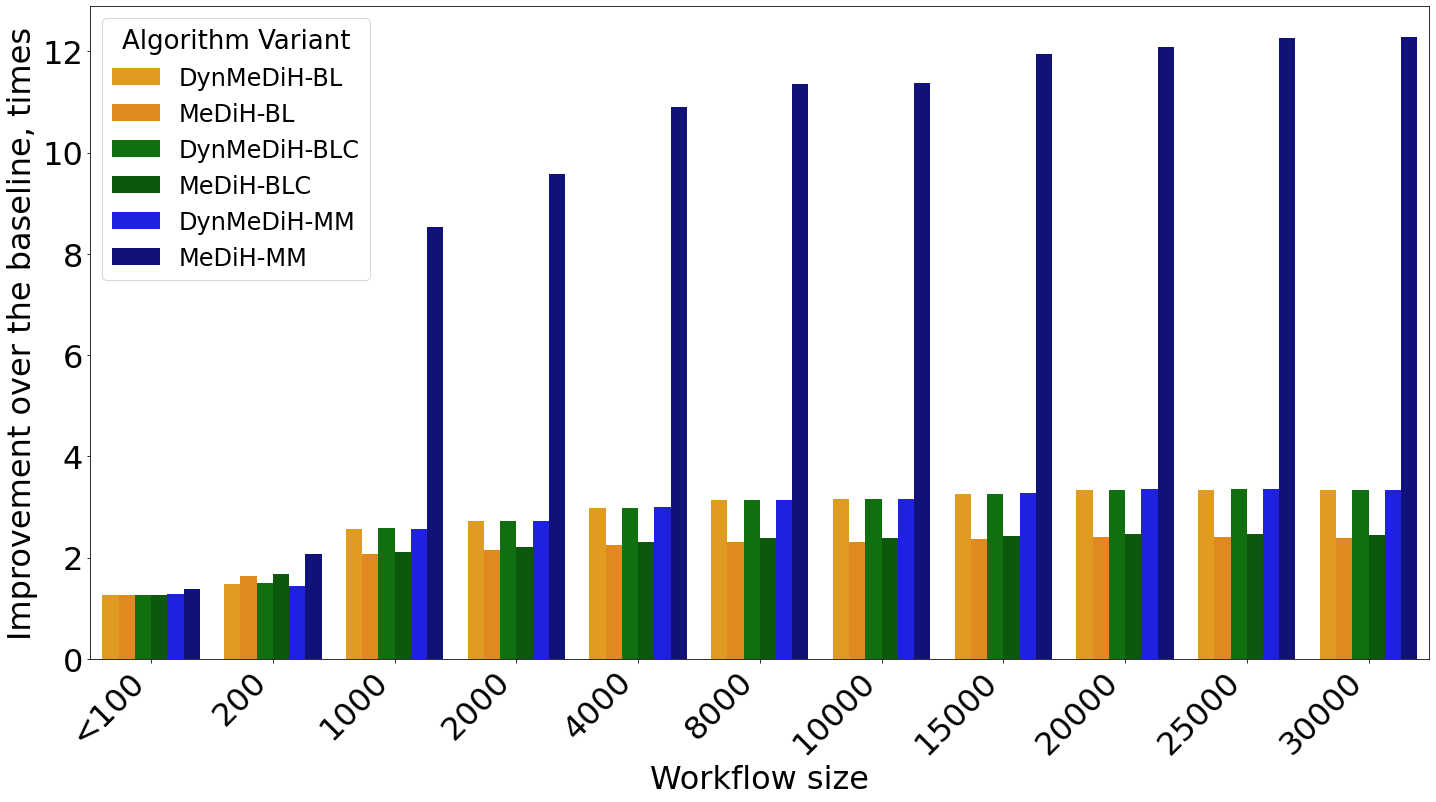

     size                   alg_rel      ratio
0     100    MeDiH-BL - dyn_vs_base   1.257127
1     100   MeDiH-BL - stat_vs_base   1.265508
2     100   MeDiH-BLC - dyn_vs_base   1.251829
3     100  MeDiH-BLC - stat_vs_base   1.265180
4     100    MeDiH-MM - dyn_vs_base   1.270639
..    ...                       ...        ...
61  30000   MeDiH-BL - stat_vs_base   2.386073
62  30000   MeDiH-BLC - dyn_vs_base   3.333133
63  30000  MeDiH-BLC - stat_vs_base   2.437897
64  30000    MeDiH-MM - dyn_vs_base   3.339607
65  30000   MeDiH-MM - stat_vs_base  12.273662

[66 rows x 3 columns]
alg_rel
MeDiH-BL - dyn_vs_base      2.653830
MeDiH-BL - stat_vs_base     2.104880
MeDiH-BLC - dyn_vs_base     2.659663
MeDiH-BLC - stat_vs_base    2.150332
MeDiH-MM - dyn_vs_base      2.658700
MeDiH-MM - stat_vs_base     7.860461
Name: ratio, dtype: float64
    algorithm size_group     ratio
3    MeDiH-BL      small  1.061677
2    MeDiH-BL     middle  0.772881
0    MeDiH-BL      large  0.726888
1    MeDiH-BL  

In [7]:
#//////////////// newest results 9/12/25 with new formula //////////////////////////
#///////////////NO DEVIATIONS////////////////////////////////
path = "./results-11-12/merged/*.txt"
print(path)

patterndevs = r'^(BASE|A\d+)-(ndev)'

dfs=read_dfs(path,patterndevs, 2)


dfsVar1 = [dfs[('A1','ndev')], dfs[('A2','ndev')], dfs[('A3','ndev')], dfs[('BASE','ndev')]]
#print(dfsVar1)
merged_df_var1 = merge_correct_columns(dfsVar1, labels)
#print(merged_df_var1)
plot_df = buld_plot_df(merged_df_var1)
plot_df = plot_df[plot_df["size"]!= 18000]

#print(plot_df)
#print(plot_df[
#    (plot_df['relation'] == 'internal') &
#    (plot_df['algorithm'] == 'MeDiH-BL') 
#   # & (~plot_df['wf_name'].str.contains('eager')) 
#   & (plot_df['ratio'] > 1.5)
#].to_string())



plotDynAndStaticVsBaseNoInset(plot_df, "no deviations", "Makespan improvement over baseline, ", ['stat_vs_base', 'dyn_vs_base'])#

allInternals = plot_df[plot_df['relation']=='internal']
allInternals = allInternals.copy()
#print(allInternals.to_string())
# Add a new column for size group
allInternals['size_group'] = allInternals['size'].apply(size_category)
# Filter only valid categories
filtered = allInternals[allInternals['size_group'] != 'other']
# Group by algorithm and size_group, then compute geometric mean
result = filtered.groupby(['algorithm', 'size_group'])['ratio'].agg(gmean).reset_index()

# Optionally, sort the result

result['size_group'] = pd.Categorical(result['size_group'], categories=size_order, ordered=True)
result = result.sort_values(['algorithm', 'size_group'])

print(result)

result2 = filtered.groupby(['algorithm', 'size'])['ratio'].agg(gmean).reset_index()
print("!!!", result2)

by_algo = allInternals.groupby('algorithm')['ratio'].agg(gmean).reset_index()
print(by_algo)

./results-11-12/merged/*.txt
No match found. A1-ndev.txt
No match found. A2-ndev.txt
No match found. BASE-dev.txt
No match found. A2-dev.txt
No match found. A3-dev.txt
No match found. A3-ndev.txt
No match found. BASE-ndev.txt


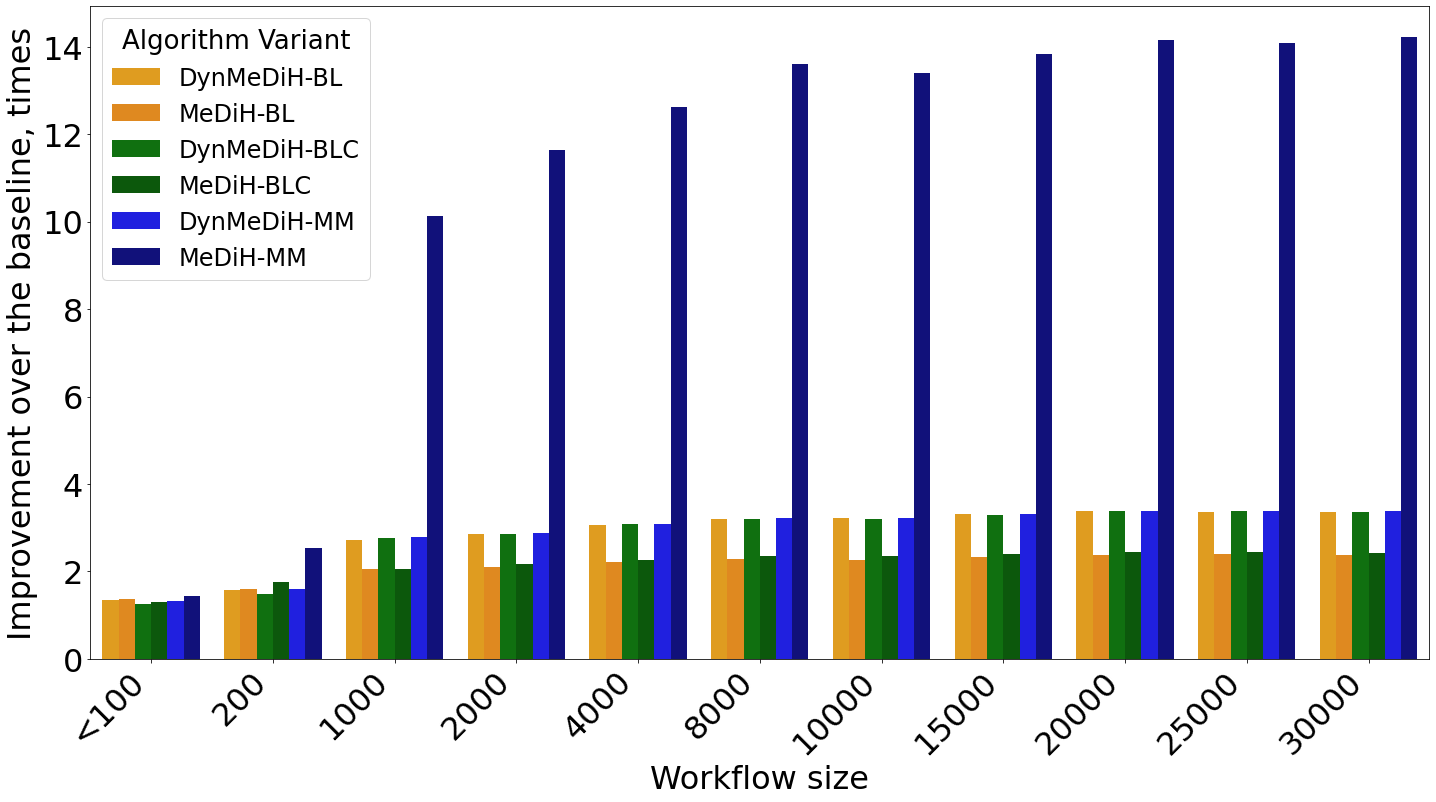

     size                   alg_rel      ratio
0     100    MeDiH-BL - dyn_vs_base   1.350656
1     100   MeDiH-BL - stat_vs_base   1.358532
2     100   MeDiH-BLC - dyn_vs_base   1.244244
3     100  MeDiH-BLC - stat_vs_base   1.302408
4     100    MeDiH-MM - dyn_vs_base   1.324065
..    ...                       ...        ...
61  30000   MeDiH-BL - stat_vs_base   2.366433
62  30000   MeDiH-BLC - dyn_vs_base   3.368565
63  30000  MeDiH-BLC - stat_vs_base   2.426323
64  30000    MeDiH-MM - dyn_vs_base   3.371665
65  30000   MeDiH-MM - stat_vs_base  14.214462

[66 rows x 3 columns]
alg_rel
MeDiH-BL - dyn_vs_base      2.742832
MeDiH-BL - stat_vs_base     2.093040
MeDiH-BLC - dyn_vs_base     2.712341
MeDiH-BLC - stat_vs_base    2.143470
MeDiH-MM - dyn_vs_base      2.754299
MeDiH-MM - stat_vs_base     9.176085
Name: ratio, dtype: float64
    algorithm size_group     ratio
3    MeDiH-BL      small  1.009441
2    MeDiH-BL     middle  0.731976
0    MeDiH-BL      large  0.704564
1    MeDiH-BL  

In [8]:
#//////////////// newest results 9/12/25 with new formula //////////////////////////
#///////////////NO DEVIATIONS////////////////////////////////
path = "./results-11-12/merged/*.txt"
print(path)

patterndevs = r'^(BASE|A\d+)-(\d\ddev)'

dfs=read_dfs(path,patterndevs, 2)


dfsVar1 = [dfs[('A1','50dev')], dfs[('A2','50dev')], dfs[('A3','50dev')], dfs[('BASE','50dev')]]
#print(dfsVar1)
merged_df_var1 = merge_correct_columns(dfsVar1, labels)
#print(merged_df_var1)
plot_df = buld_plot_df(merged_df_var1)
plot_df = plot_df[plot_df["size"]!= 18000]

#print(plot_df)
#print(plot_df[
#    (plot_df['relation'] == 'internal') &
#    (plot_df['algorithm'] == 'MeDiH-BL') 
#   # & (~plot_df['wf_name'].str.contains('eager')) 
#   & (plot_df['ratio'] > 1.5)
#].to_string())



plotDynAndStaticVsBaseNoInset(plot_df, "largest deviations", "Makespan improvement over baseline, ", ['stat_vs_base', 'dyn_vs_base'])#

allInternals = plot_df[plot_df['relation']=='internal']
allInternals = allInternals.copy()
#print(allInternals.to_string())
# Add a new column for size group
allInternals['size_group'] = allInternals['size'].apply(size_category)
# Filter only valid categories
filtered = allInternals[allInternals['size_group'] != 'other']
# Group by algorithm and size_group, then compute geometric mean
result = filtered.groupby(['algorithm', 'size_group'])['ratio'].agg(gmean).reset_index()

# Optionally, sort the result

result['size_group'] = pd.Categorical(result['size_group'], categories=size_order, ordered=True)
result = result.sort_values(['algorithm', 'size_group'])

print(result)

result2 = filtered.groupby(['algorithm', 'size'])['ratio'].agg(gmean).reset_index()
print("!!!", result2)

by_algo = allInternals.groupby('algorithm')['ratio'].agg(gmean).reset_index()
print(by_algo)

./results-17-12/merged/*.txt


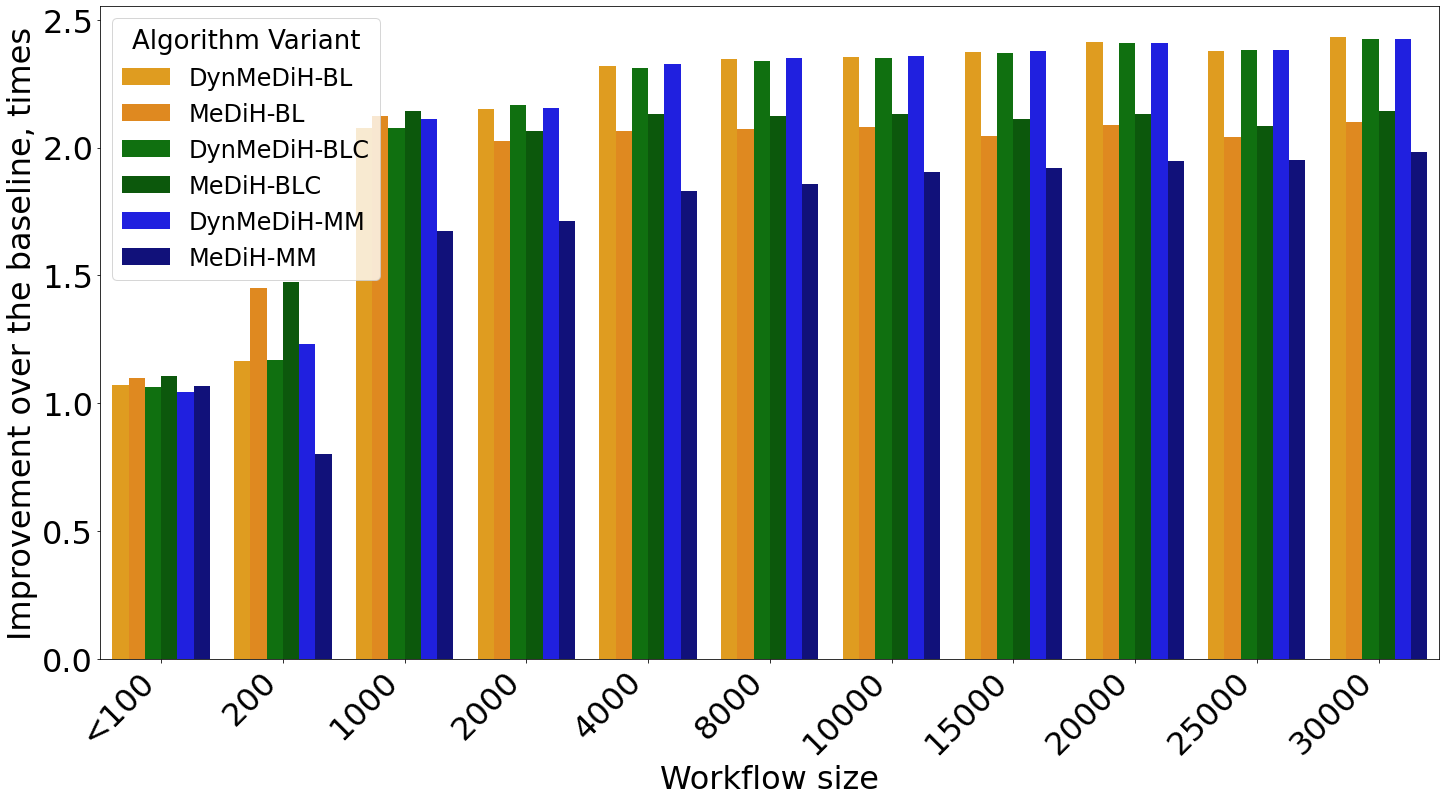

     size                   alg_rel     ratio
0     100    MeDiH-BL - dyn_vs_base  1.070250
1     100   MeDiH-BL - stat_vs_base  1.097715
2     100   MeDiH-BLC - dyn_vs_base  1.064379
3     100  MeDiH-BLC - stat_vs_base  1.107475
4     100    MeDiH-MM - dyn_vs_base  1.045062
..    ...                       ...       ...
61  30000   MeDiH-BL - stat_vs_base  2.102245
62  30000   MeDiH-BLC - dyn_vs_base  2.426338
63  30000  MeDiH-BLC - stat_vs_base  2.143272
64  30000    MeDiH-MM - dyn_vs_base  2.424898
65  30000   MeDiH-MM - stat_vs_base  1.982194

[66 rows x 3 columns]
alg_rel
MeDiH-BL - dyn_vs_base      2.026647
MeDiH-BL - stat_vs_base     1.893531
MeDiH-BLC - dyn_vs_base     2.024954
MeDiH-BLC - stat_vs_base    1.932681
MeDiH-MM - dyn_vs_base      2.036440
MeDiH-MM - stat_vs_base     1.639310
Name: ratio, dtype: float64
   algorithm size_group     ratio
0   MeDiH-BL        NaN  0.863339
1   MeDiH-BL        NaN  0.875804
2   MeDiH-BL        NaN  1.018438
3  MeDiH-BLC        NaN  0.8812

In [6]:
#//////////////// newest results 17/12/25 with new formula //////////////////////////
#///////////////NO DEVIATIONS////////////////////////////////
path = "./results-17-12/merged/*.txt"
print(path)

patterndevs = r'^(BASE|A\d+)-(ndev)'

dfs=read_dfs(path,patterndevs, 2)


dfsVar1 = [dfs[('A1','ndev')], dfs[('A2','ndev')], dfs[('A3','ndev')], dfs[('BASE','ndev')]]
#print(dfsVar1)
merged_df_var1 = merge_correct_columns(dfsVar1, labels)
#print(merged_df_var1)
plot_df = buld_plot_df(merged_df_var1)
plot_df = plot_df[plot_df["size"]!= 18000]

#print(plot_df)
#print(plot_df[
#    (plot_df['relation'] == 'internal') &
#    (plot_df['algorithm'] == 'MeDiH-BL') 
#   # & (~plot_df['wf_name'].str.contains('eager')) 
#   & (plot_df['ratio'] > 1.5)
#].to_string())



plotDynAndStaticVsBaseNoInset(plot_df, "no_deviations", "Makespan improvement over baseline, ", ['stat_vs_base', 'dyn_vs_base'])#

allInternals = plot_df[plot_df['relation']=='internal']
allInternals = allInternals.copy()
#print(allInternals.to_string())
# Add a new column for size group
allInternals['size_group'] = allInternals['size'].apply(size_category)
# Filter only valid categories
filtered = allInternals[allInternals['size_group'] != 'other']
# Group by algorithm and size_group, then compute geometric mean
result = filtered.groupby(['algorithm', 'size_group'])['ratio'].agg(gmean).reset_index()

# Optionally, sort the result

result['size_group'] = pd.Categorical(result['size_group'], categories=size_order, ordered=True)
result = result.sort_values(['algorithm', 'size_group'])

print(result)

result2 = filtered.groupby(['algorithm', 'size'])['ratio'].agg(gmean).reset_index()
print("!!!", result2)

by_algo = allInternals.groupby('algorithm')['ratio'].agg(gmean).reset_index()
print(by_algo)

./results-17-12/merged/*.txt


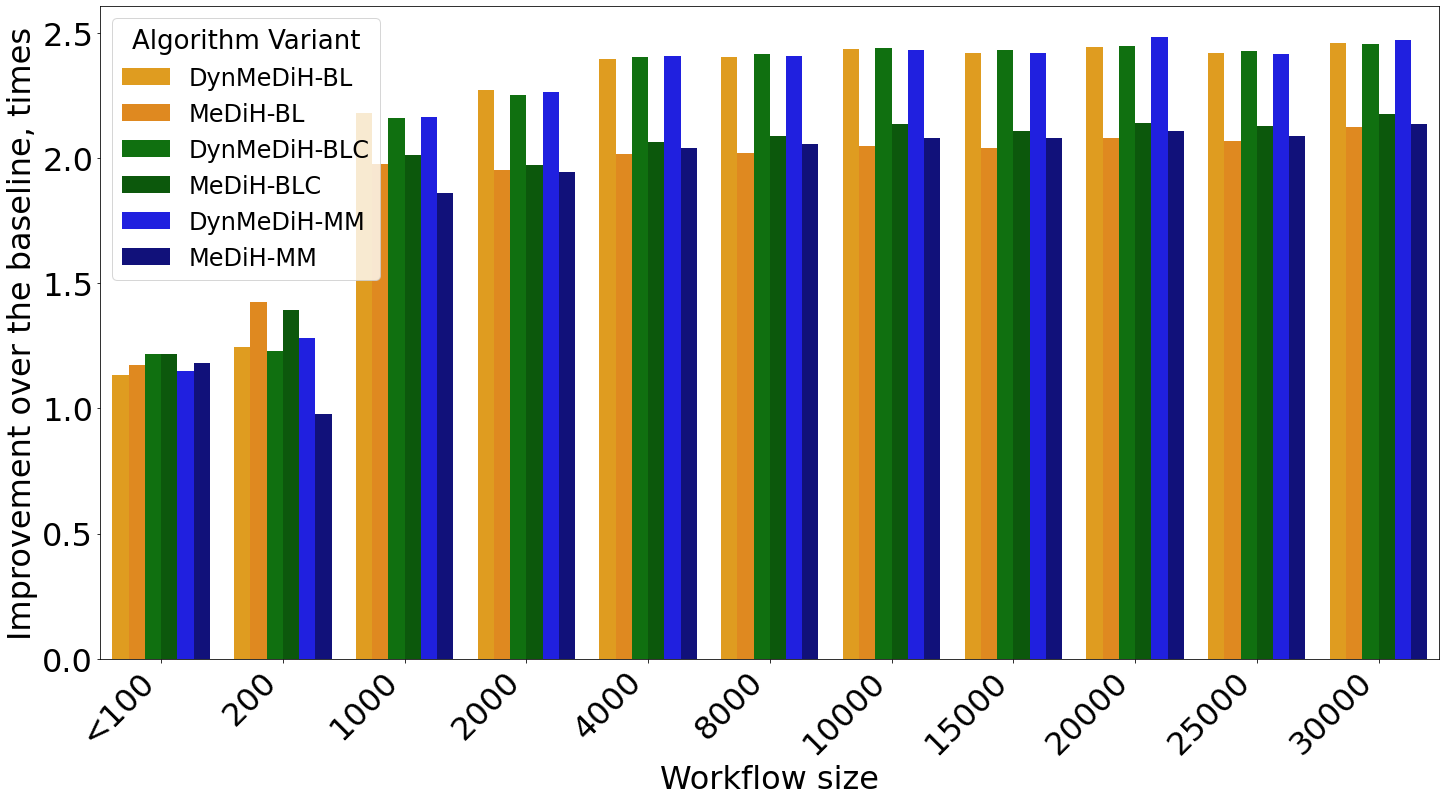

     size                   alg_rel     ratio
0     100    MeDiH-BL - dyn_vs_base  1.131781
1     100   MeDiH-BL - stat_vs_base  1.172622
2     100   MeDiH-BLC - dyn_vs_base  1.217589
3     100  MeDiH-BLC - stat_vs_base  1.216609
4     100    MeDiH-MM - dyn_vs_base  1.150040
..    ...                       ...       ...
61  30000   MeDiH-BL - stat_vs_base  2.125446
62  30000   MeDiH-BLC - dyn_vs_base  2.454296
63  30000  MeDiH-BLC - stat_vs_base  2.177588
64  30000    MeDiH-MM - dyn_vs_base  2.470740
65  30000   MeDiH-MM - stat_vs_base  2.135526

[66 rows x 3 columns]
alg_rel
MeDiH-BL - dyn_vs_base      2.097504
MeDiH-BL - stat_vs_base     1.874767
MeDiH-BLC - dyn_vs_base     2.108909
MeDiH-BLC - stat_vs_base    1.918759
MeDiH-MM - dyn_vs_base      2.107899
MeDiH-MM - stat_vs_base     1.817671
Name: ratio, dtype: float64
   algorithm size_group     ratio
0   MeDiH-BL        NaN  0.856411
1   MeDiH-BL        NaN  0.841209
2   MeDiH-BL        NaN  0.951012
3  MeDiH-BLC        NaN  0.8788

In [7]:
#//////////////// newest results 17/12/25 with new formula //////////////////////////
#///////////////LARGEST DEVIATIONS////////////////////////////////
path = "./results-17-12/merged/*.txt"
print(path)

patterndevs = r'^(BASE|A\d+)-(bdev)'

dfs=read_dfs(path,patterndevs, 2)


dfsVar1 = [dfs[('A1','bdev')], dfs[('A2','bdev')], dfs[('A3','bdev')], dfs[('BASE','bdev')]]
#print(dfsVar1)
merged_df_var1 = merge_correct_columns(dfsVar1, labels)
#print(merged_df_var1)
plot_df = buld_plot_df(merged_df_var1)
plot_df = plot_df[plot_df["size"]!= 18000]

#print(plot_df)
#print(plot_df[
#    (plot_df['relation'] == 'internal') &
#    (plot_df['algorithm'] == 'MeDiH-BL') 
#   # & (~plot_df['wf_name'].str.contains('eager')) 
#   & (plot_df['ratio'] > 1.5)
#].to_string())



plotDynAndStaticVsBaseNoInset(plot_df, "largest_deviations", "Makespan improvement over baseline, ", ['stat_vs_base', 'dyn_vs_base'])#

allInternals = plot_df[plot_df['relation']=='internal']
allInternals = allInternals.copy()
#print(allInternals.to_string())
# Add a new column for size group
allInternals['size_group'] = allInternals['size'].apply(size_category)
# Filter only valid categories
filtered = allInternals[allInternals['size_group'] != 'other']
# Group by algorithm and size_group, then compute geometric mean
result = filtered.groupby(['algorithm', 'size_group'])['ratio'].agg(gmean).reset_index()

# Optionally, sort the result

result['size_group'] = pd.Categorical(result['size_group'], categories=size_order, ordered=True)
result = result.sort_values(['algorithm', 'size_group'])

print(result)

result2 = filtered.groupby(['algorithm', 'size'])['ratio'].agg(gmean).reset_index()
print("!!!", result2)

by_algo = allInternals.groupby('algorithm')['ratio'].agg(gmean).reset_index()
print(by_algo)

./results-18-12/merged/*.txt


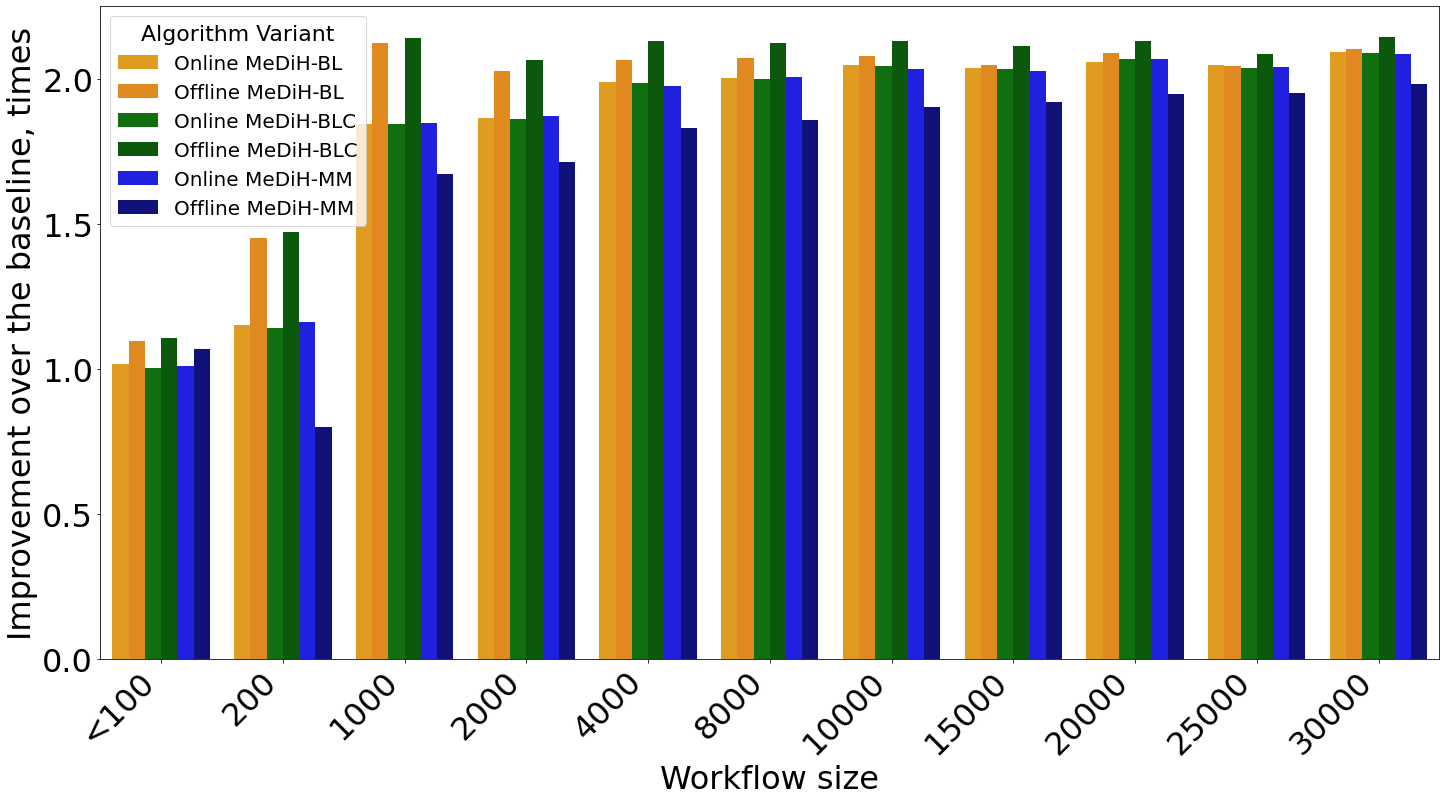

     size                   alg_rel     ratio
0     100    MeDiH-BL - dyn_vs_base  1.015898
1     100   MeDiH-BL - stat_vs_base  1.097715
2     100   MeDiH-BLC - dyn_vs_base  1.002949
3     100  MeDiH-BLC - stat_vs_base  1.107475
4     100    MeDiH-MM - dyn_vs_base  1.011067
..    ...                       ...       ...
61  30000   MeDiH-BL - stat_vs_base  2.102245
62  30000   MeDiH-BLC - dyn_vs_base  2.091309
63  30000  MeDiH-BLC - stat_vs_base  2.143272
64  30000    MeDiH-MM - dyn_vs_base  2.084874
65  30000   MeDiH-MM - stat_vs_base  1.982194

[66 rows x 3 columns]
alg_rel
MeDiH-BL - dyn_vs_base      1.786925
MeDiH-BL - stat_vs_base     1.893531
MeDiH-BLC - dyn_vs_base     1.781197
MeDiH-BLC - stat_vs_base    1.932681
MeDiH-MM - dyn_vs_base      1.784880
MeDiH-MM - stat_vs_base     1.639310
Name: ratio, dtype: float64
    algorithm size_group     ratio
3    MeDiH-BL      small  1.166662
2    MeDiH-BL     middle  1.076368
0    MeDiH-BL      large  1.009750
1    MeDiH-BL    largest  1

In [19]:
#//////////////// newest results 18/12/25 with new formula //////////////////////////
#///////////////NO DEVIATIONS////////////////////////////////
path = "./results-18-12/merged/*.txt"
print(path)

patterndevs = r'^(BASE|A\d+)-(ndev)'

dfs=read_dfs(path,patterndevs, 2)


dfsVar1 = [dfs[('A1','ndev')], dfs[('A2','ndev')], dfs[('A3','ndev')], dfs[('BASE','ndev')]]
#print(dfsVar1)
merged_df_var1 = merge_correct_columns(dfsVar1, labels)
#print(merged_df_var1)
plot_df = buld_plot_df(merged_df_var1)
plot_df = plot_df[plot_df["size"]!= 18000]

#print(plot_df)
#print(plot_df[
#    (plot_df['relation'] == 'internal') &
#    (plot_df['algorithm'] == 'MeDiH-BL') 
#   # & (~plot_df['wf_name'].str.contains('eager')) 
#   & (plot_df['ratio'] > 1.5)
#].to_string())



plotDynAndStaticVsBaseNoInset(plot_df, "no_deviations", "Makespan improvement over baseline, ", ['stat_vs_base', 'dyn_vs_base'])#

allInternals = plot_df[plot_df['relation']=='internal']
allInternals = allInternals.copy()
#print(allInternals.to_string())
# Add a new column for size group
allInternals['size_group'] = allInternals['size'].apply(size_category)
# Filter only valid categories
filtered = allInternals[allInternals['size_group'] != 'other']
# Group by algorithm and size_group, then compute geometric mean
result = filtered.groupby(['algorithm', 'size_group'])['ratio'].agg(gmean).reset_index()

# Optionally, sort the result

result['size_group'] = pd.Categorical(result['size_group'], categories=size_order, ordered=True)
result = result.sort_values(['algorithm', 'size_group'])

print(result)

result2 = filtered.groupby(['algorithm', 'size'])['ratio'].agg(gmean).reset_index()
print("!!!", result2)

by_algo = allInternals.groupby('algorithm')['ratio'].agg(gmean).reset_index()
print(by_algo)

./results-18-12/merged/*.txt


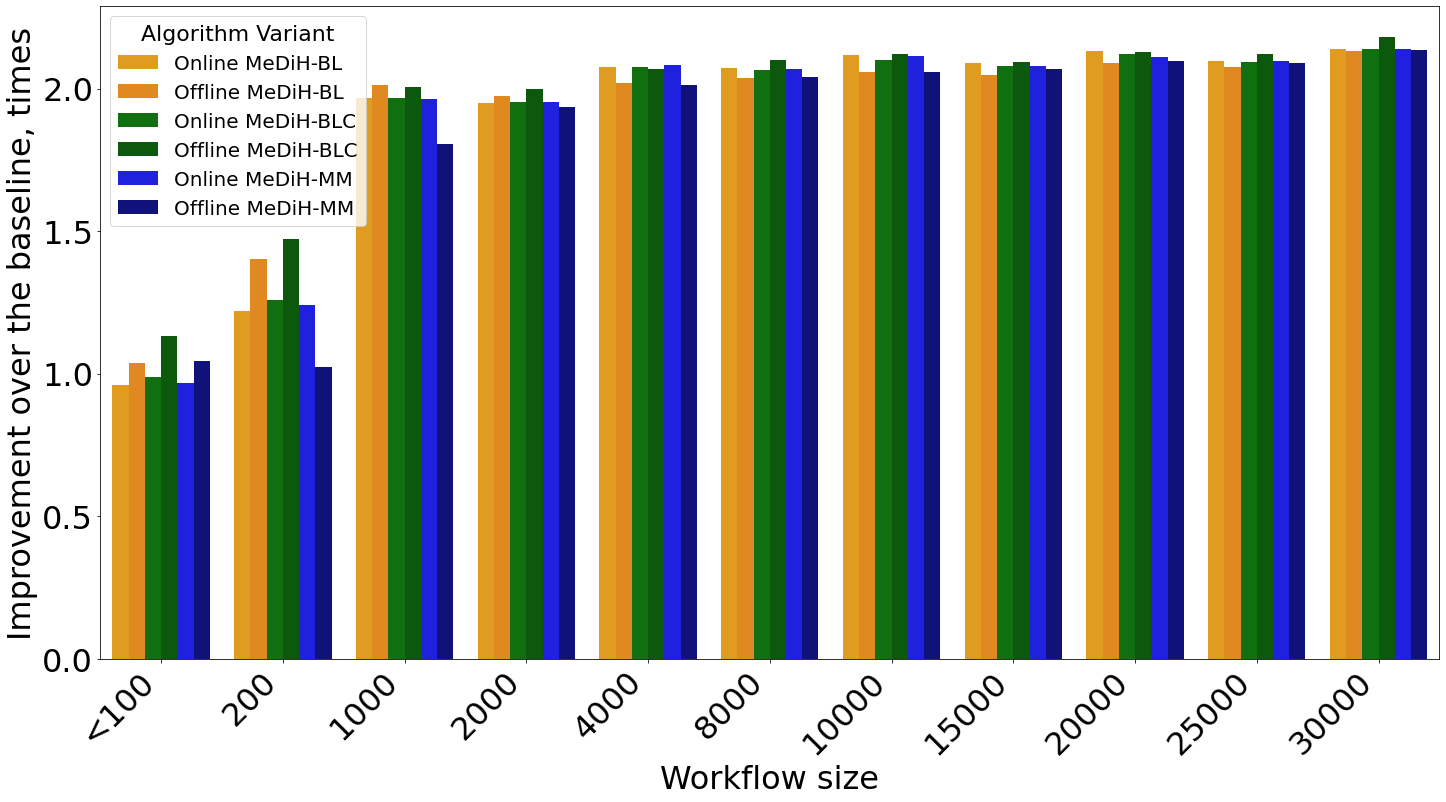

     size                   alg_rel     ratio
0     100    MeDiH-BL - dyn_vs_base  0.961819
1     100   MeDiH-BL - stat_vs_base  1.035966
2     100   MeDiH-BLC - dyn_vs_base  0.989371
3     100  MeDiH-BLC - stat_vs_base  1.133839
4     100    MeDiH-MM - dyn_vs_base  0.967846
..    ...                       ...       ...
61  30000   MeDiH-BL - stat_vs_base  2.133765
62  30000   MeDiH-BLC - dyn_vs_base  2.140378
63  30000  MeDiH-BLC - stat_vs_base  2.179531
64  30000    MeDiH-MM - dyn_vs_base  2.139409
65  30000   MeDiH-MM - stat_vs_base  2.137124

[66 rows x 3 columns]
alg_rel
MeDiH-BL - dyn_vs_base      1.840101
MeDiH-BL - stat_vs_base     1.860639
MeDiH-BLC - dyn_vs_base     1.847279
MeDiH-BLC - stat_vs_base    1.915439
MeDiH-MM - dyn_vs_base      1.841108
MeDiH-MM - stat_vs_base     1.792248
Name: ratio, dtype: float64
    algorithm size_group     ratio
3    MeDiH-BL      small  1.113024
2    MeDiH-BL     middle  0.997434
0    MeDiH-BL      large  0.975688
1    MeDiH-BL    largest  0

In [20]:
#//////////////// newest results 18/12/25 with new formula //////////////////////////
#///////////////LARGEST DEVIATIONS////////////////////////////////
path = "./results-18-12/merged/*.txt"
print(path)

patterndevs = r'^(BASE|A\d+)-(\d\ddev)'

dfs=read_dfs(path,patterndevs, 2)


dfsVar1 = [dfs[('A1','50dev')], dfs[('A2','50dev')], dfs[('A3','50dev')], dfs[('BASE','50dev')]]
#print(dfsVar1)
merged_df_var1 = merge_correct_columns(dfsVar1, labels)
#print(merged_df_var1)
plot_df = buld_plot_df(merged_df_var1)
plot_df = plot_df[plot_df["size"]!= 18000]

#print(plot_df)
#print(plot_df[
#    (plot_df['relation'] == 'internal') &
#    (plot_df['algorithm'] == 'MeDiH-BL') 
#   # & (~plot_df['wf_name'].str.contains('eager')) 
#   & (plot_df['ratio'] > 1.5)
#].to_string())



plotDynAndStaticVsBaseNoInset(plot_df, "largest_deviations", "Makespan improvement over baseline, ", ['stat_vs_base', 'dyn_vs_base'])#

allInternals = plot_df[plot_df['relation']=='internal']
allInternals = allInternals.copy()
#print(allInternals.to_string())
# Add a new column for size group
allInternals['size_group'] = allInternals['size'].apply(size_category)
# Filter only valid categories
filtered = allInternals[allInternals['size_group'] != 'other']
# Group by algorithm and size_group, then compute geometric mean
result = filtered.groupby(['algorithm', 'size_group'])['ratio'].agg(gmean).reset_index()

# Optionally, sort the result

result['size_group'] = pd.Categorical(result['size_group'], categories=size_order, ordered=True)
result = result.sort_values(['algorithm', 'size_group'])

print(result)

result2 = filtered.groupby(['algorithm', 'size'])['ratio'].agg(gmean).reset_index()
print("!!!", result2)

by_algo = allInternals.groupby('algorithm')['ratio'].agg(gmean).reset_index()
print(by_algo)

./results-18-12/merged/*.txt


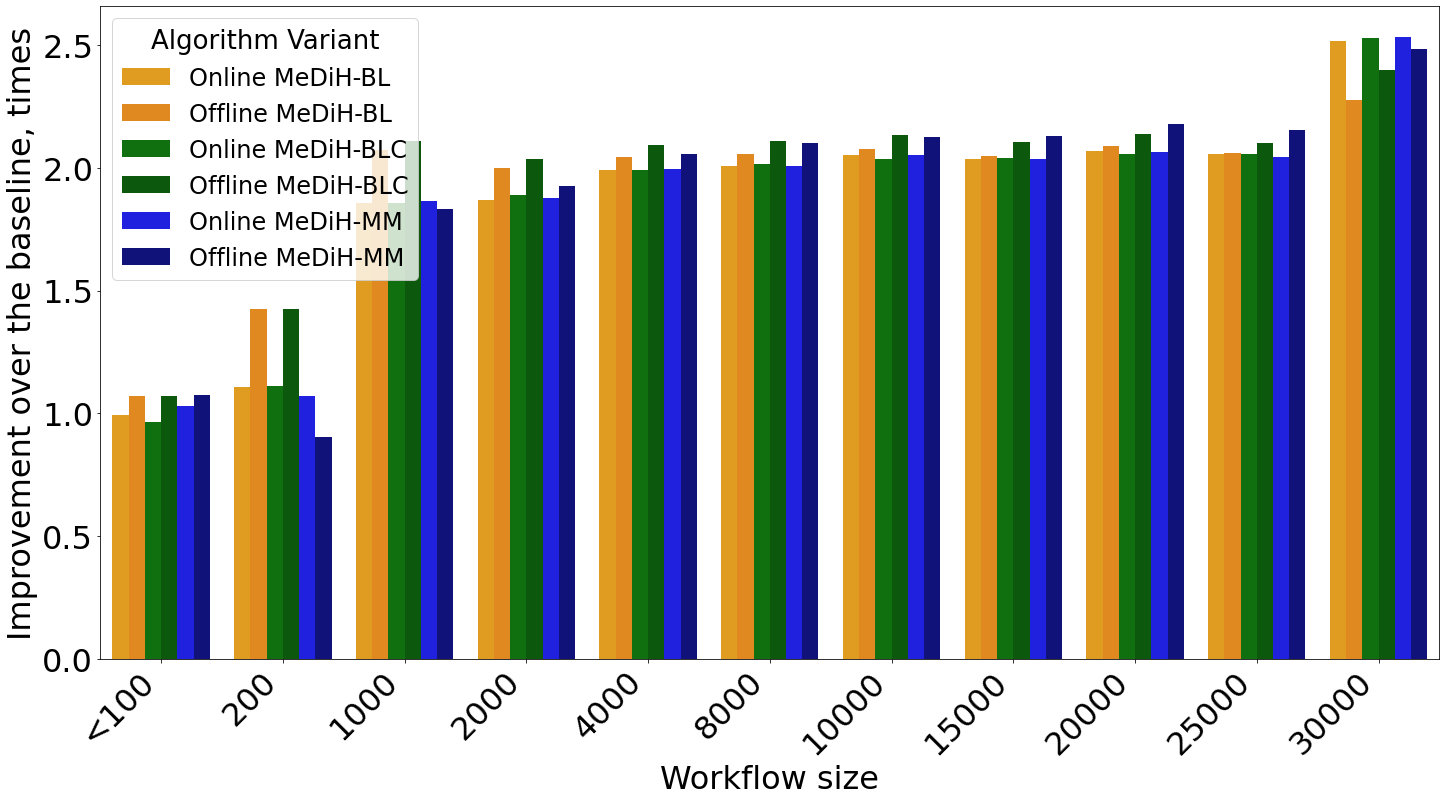

     size                   alg_rel     ratio
0     100    MeDiH-BL - dyn_vs_base  0.992222
1     100   MeDiH-BL - stat_vs_base  1.070298
2     100   MeDiH-BLC - dyn_vs_base  0.964020
3     100  MeDiH-BLC - stat_vs_base  1.068910
4     100    MeDiH-MM - dyn_vs_base  1.028654
..    ...                       ...       ...
61  30000   MeDiH-BL - stat_vs_base  2.276513
62  30000   MeDiH-BLC - dyn_vs_base  2.527543
63  30000  MeDiH-BLC - stat_vs_base  2.396211
64  30000    MeDiH-MM - dyn_vs_base  2.530637
65  30000   MeDiH-MM - stat_vs_base  2.484445

[66 rows x 3 columns]
alg_rel
MeDiH-BL - dyn_vs_base      1.809375
MeDiH-BL - stat_vs_base     1.890869
MeDiH-BLC - dyn_vs_base     1.805897
MeDiH-BLC - stat_vs_base    1.931493
MeDiH-MM - dyn_vs_base      1.811123
MeDiH-MM - stat_vs_base     1.832762
Name: ratio, dtype: float64
    algorithm size_group     ratio
3    MeDiH-BL      small  1.177658
2    MeDiH-BL     middle  1.058738
0    MeDiH-BL      large  1.008752
1    MeDiH-BL    largest  0

In [15]:
#//////////////// newest results 18/12/25 with new formula //////////////////////////
#///////////////SMALL DEVIATIONS////////////////////////////////
path = "./results-18-12/merged/*.txt"
print(path)

patterndevs = r'^(BASE|A\d+)-(\d\ddev)'

dfs=read_dfs(path,patterndevs, 2)


dfsVar1 = [dfs[('A1','10dev')], dfs[('A2','10dev')], dfs[('A3','10dev')], dfs[('BASE','10dev')]]
#print(dfsVar1)
merged_df_var1 = merge_correct_columns(dfsVar1, labels)
#print(merged_df_var1)
plot_df = buld_plot_df(merged_df_var1)
plot_df = plot_df[plot_df["size"]!= 18000]

#print(plot_df)
#print(plot_df[
#    (plot_df['relation'] == 'internal') &
#    (plot_df['algorithm'] == 'MeDiH-BL') 
#   # & (~plot_df['wf_name'].str.contains('eager')) 
#   & (plot_df['ratio'] > 1.5)
#].to_string())



plotDynAndStaticVsBaseNoInset(plot_df, "small_deviations", "Makespan improvement over baseline, ", ['stat_vs_base', 'dyn_vs_base'])#

allInternals = plot_df[plot_df['relation']=='internal']
allInternals = allInternals.copy()
#print(allInternals.to_string())
# Add a new column for size group
allInternals['size_group'] = allInternals['size'].apply(size_category)
# Filter only valid categories
filtered = allInternals[allInternals['size_group'] != 'other']
# Group by algorithm and size_group, then compute geometric mean
result = filtered.groupby(['algorithm', 'size_group'])['ratio'].agg(gmean).reset_index()

# Optionally, sort the result

result['size_group'] = pd.Categorical(result['size_group'], categories=size_order, ordered=True)
result = result.sort_values(['algorithm', 'size_group'])

print(result)

result2 = filtered.groupby(['algorithm', 'size'])['ratio'].agg(gmean).reset_index()
print("!!!", result2)

by_algo = allInternals.groupby('algorithm')['ratio'].agg(gmean).reset_index()
print(by_algo)

./results-18-12/merged/*.txt


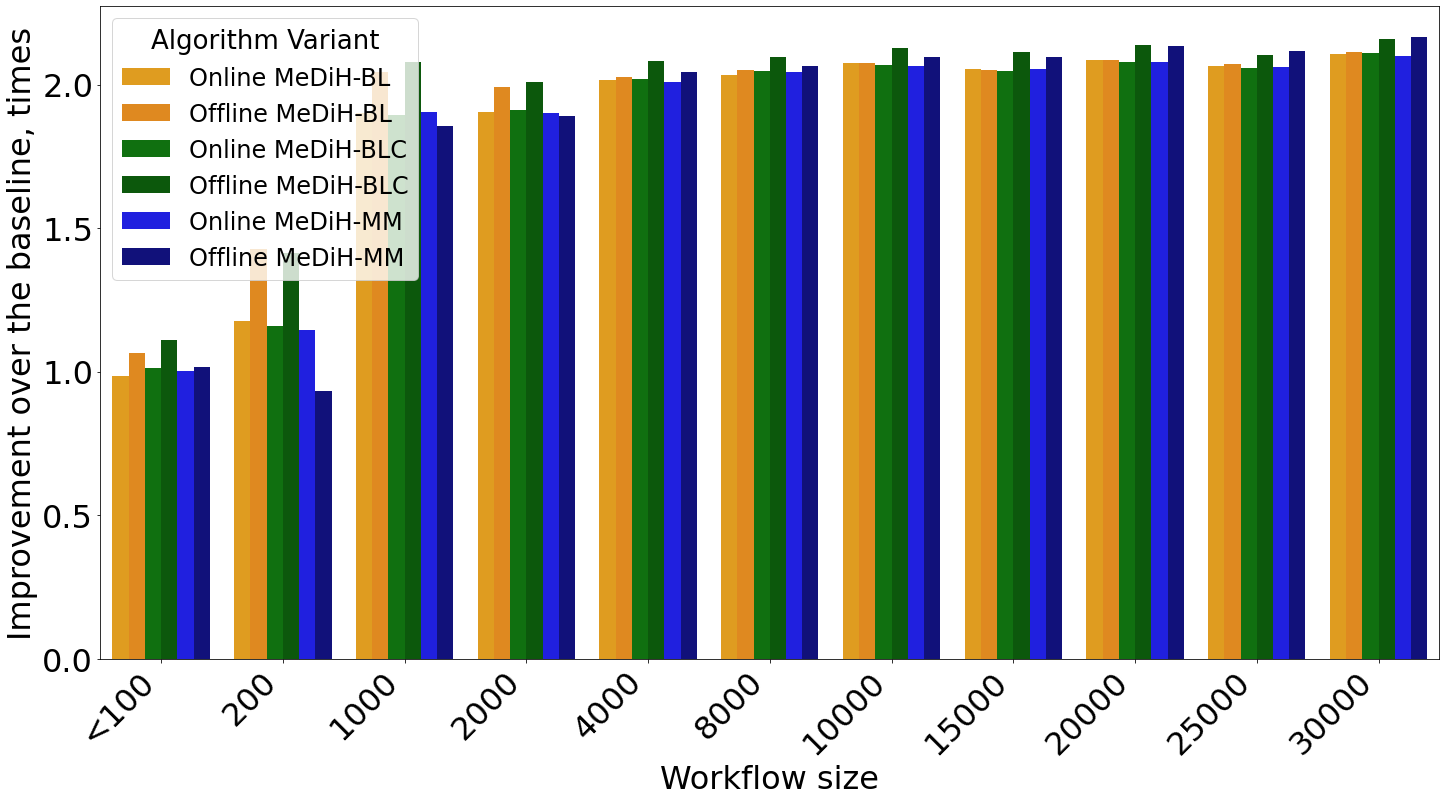

     size                   alg_rel     ratio
0     100    MeDiH-BL - dyn_vs_base  0.984360
1     100   MeDiH-BL - stat_vs_base  1.066198
2     100   MeDiH-BLC - dyn_vs_base  1.013656
3     100  MeDiH-BLC - stat_vs_base  1.110723
4     100    MeDiH-MM - dyn_vs_base  1.001671
..    ...                       ...       ...
61  30000   MeDiH-BL - stat_vs_base  2.114738
62  30000   MeDiH-BLC - dyn_vs_base  2.109788
63  30000  MeDiH-BLC - stat_vs_base  2.158707
64  30000    MeDiH-MM - dyn_vs_base  2.099772
65  30000   MeDiH-MM - stat_vs_base  2.164471

[66 rows x 3 columns]
alg_rel
MeDiH-BL - dyn_vs_base      1.805612
MeDiH-BL - stat_vs_base     1.873806
MeDiH-BLC - dyn_vs_base     1.807359
MeDiH-BLC - stat_vs_base    1.912215
MeDiH-MM - dyn_vs_base      1.802255
MeDiH-MM - stat_vs_base     1.789742
Name: ratio, dtype: float64
    algorithm size_group     ratio
3    MeDiH-BL      small  1.146890
2    MeDiH-BL     middle  1.032850
0    MeDiH-BL      large  0.998577
1    MeDiH-BL    largest  1

In [16]:
#//////////////// newest results 18/12/25 with new formula //////////////////////////
#///////////////MIDDLE DEVIATIONS////////////////////////////////
path = "./results-18-12/merged/*.txt"
print(path)

patterndevs = r'^(BASE|A\d+)-(\d\ddev)'

dfs=read_dfs(path,patterndevs, 2)


dfsVar1 = [dfs[('A1','30dev')], dfs[('A2','30dev')], dfs[('A3','30dev')], dfs[('BASE','30dev')]]
#print(dfsVar1)
merged_df_var1 = merge_correct_columns(dfsVar1, labels)
#print(merged_df_var1)
plot_df = buld_plot_df(merged_df_var1)
plot_df = plot_df[plot_df["size"]!= 18000]

#print(plot_df)
#print(plot_df[
#    (plot_df['relation'] == 'internal') &
#    (plot_df['algorithm'] == 'MeDiH-BL') 
#   # & (~plot_df['wf_name'].str.contains('eager')) 
#   & (plot_df['ratio'] > 1.5)
#].to_string())


#print(plot_df.head())

plotDynAndStaticVsBaseNoInset(plot_df, "medium_deviations", "Makespan improvement over baseline, ", ['stat_vs_base', 'dyn_vs_base'])#

allInternals = plot_df[plot_df['relation']=='internal']
allInternals = allInternals.copy()
#print(allInternals.to_string())
# Add a new column for size group
allInternals['size_group'] = allInternals['size'].apply(size_category)
# Filter only valid categories
filtered = allInternals[allInternals['size_group'] != 'other']
# Group by algorithm and size_group, then compute geometric mean
result = filtered.groupby(['algorithm', 'size_group'])['ratio'].agg(gmean).reset_index()

# Optionally, sort the result

result['size_group'] = pd.Categorical(result['size_group'], categories=size_order, ordered=True)
result = result.sort_values(['algorithm', 'size_group'])

print(result)

result2 = filtered.groupby(['algorithm', 'size'])['ratio'].agg(gmean).reset_index()
print("!!!", result2)

by_algo = allInternals.groupby('algorithm')['ratio'].agg(gmean).reset_index()
print(by_algo)

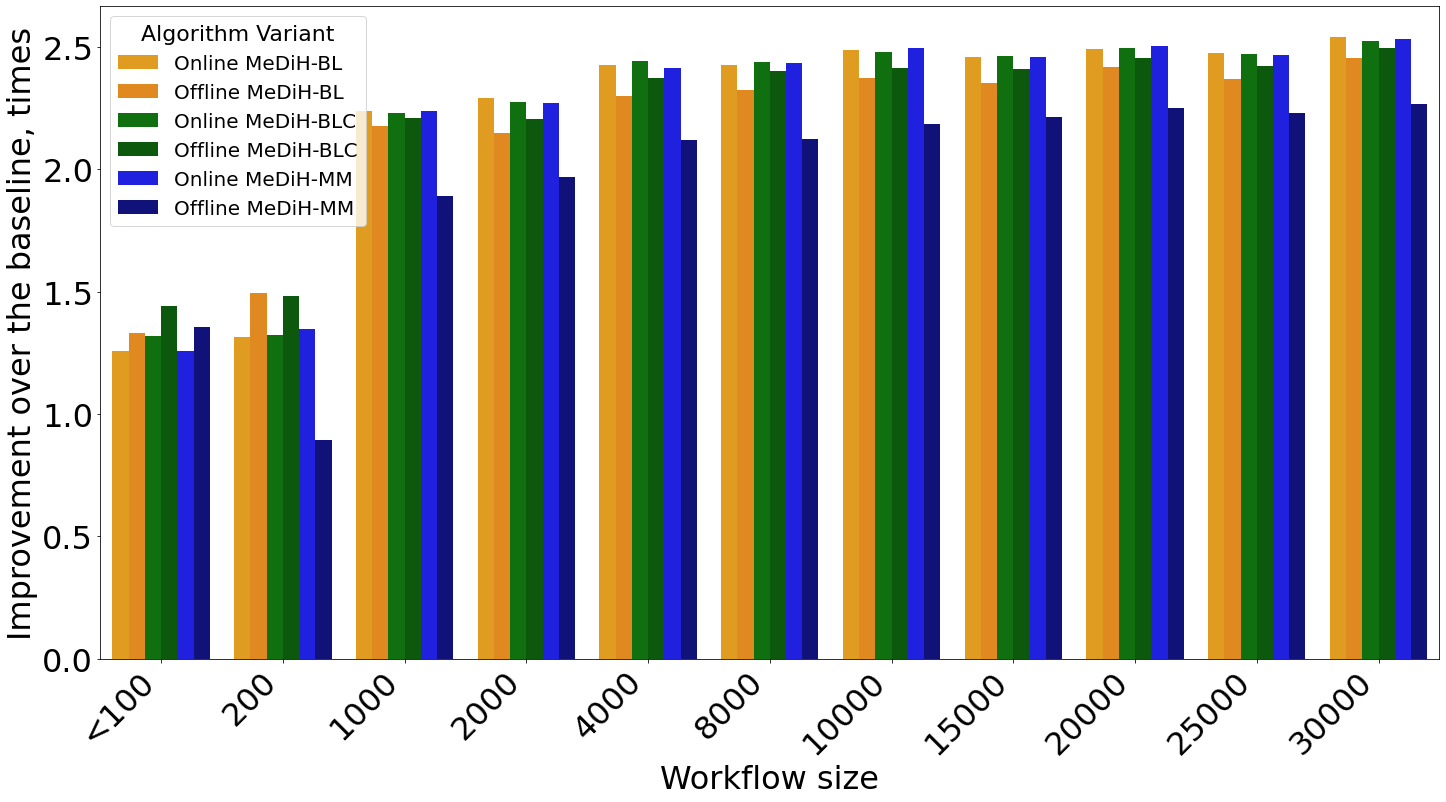

     size                   alg_rel     ratio
0     100    MeDiH-BL - dyn_vs_base  1.256415
1     100   MeDiH-BL - stat_vs_base  1.331718
2     100   MeDiH-BLC - dyn_vs_base  1.320144
3     100  MeDiH-BLC - stat_vs_base  1.440010
4     100    MeDiH-MM - dyn_vs_base  1.257884
..    ...                       ...       ...
61  30000   MeDiH-BL - stat_vs_base  2.454988
62  30000   MeDiH-BLC - dyn_vs_base  2.524474
63  30000  MeDiH-BLC - stat_vs_base  2.498036
64  30000    MeDiH-MM - dyn_vs_base  2.531969
65  30000   MeDiH-MM - stat_vs_base  2.268959

[66 rows x 3 columns]
alg_rel
MeDiH-BL - dyn_vs_base      2.160798
MeDiH-BL - stat_vs_base     2.121730
MeDiH-BLC - dyn_vs_base     2.170421
MeDiH-BLC - stat_vs_base    2.175066
MeDiH-MM - dyn_vs_base      2.163883
MeDiH-MM - stat_vs_base     1.893182
Name: ratio, dtype: float64
    algorithm size_group     ratio
3    MeDiH-BL      small  1.098192
2    MeDiH-BL     middle  0.954214
0    MeDiH-BL      large  0.954806
1    MeDiH-BL    largest  0

In [8]:
#//////////////// newest results 26/12/25 with new formula //////////////////////////

path = "./results-26-12/merged/*.txt"
#print(path)

patterndevs = r'^(BASE|A\d+)-(bdev)'

dfs26=read_dfs(path,patterndevs, 2)

#print(dfs)
dfsVar1 = [dfs26[('A1','bdev')], dfs26[('A2','bdev')], dfs26[('A3','bdev')], dfs26[('BASE','bdev')]]
#print(dfsVar1)
merged_df_var1 = merge_correct_columns(dfsVar1, labels)
#print(merged_df_var1)
plot_df = buld_plot_df(merged_df_var1)
plot_df = plot_df[plot_df["size"]!= 18000]

#print(plot_df)
#print(plot_df[
#    (plot_df['relation'] == 'internal') &
#    (plot_df['algorithm'] == 'MeDiH-BL') 
#   # & (~plot_df['wf_name'].str.contains('eager')) 
#   & (plot_df['ratio'] > 1.5)
#].to_string())



plotDynAndStaticVsBaseNoInset(plot_df, "largest_deviations", "Makespan improvement over baseline, ", ['stat_vs_base', 'dyn_vs_base'])#

allInternals = plot_df[plot_df['relation']=='internal']
allInternals = allInternals.copy()
#print(allInternals.to_string())
# Add a new column for size group
allInternals['size_group'] = allInternals['size'].apply(size_category)
# Filter only valid categories
filtered = allInternals[allInternals['size_group'] != 'other']
# Group by algorithm and size_group, then compute geometric mean
result = filtered.groupby(['algorithm', 'size_group'])['ratio'].agg(gmean).reset_index()

# Optionally, sort the result

result['size_group'] = pd.Categorical(result['size_group'], categories=size_order, ordered=True)
result = result.sort_values(['algorithm', 'size_group'])

print(result)

result2 = filtered.groupby(['algorithm', 'size'])['ratio'].agg(gmean).reset_index()
print("!!!", result2)

by_algo = allInternals.groupby('algorithm')['ratio'].agg(gmean).reset_index()
print(by_algo)

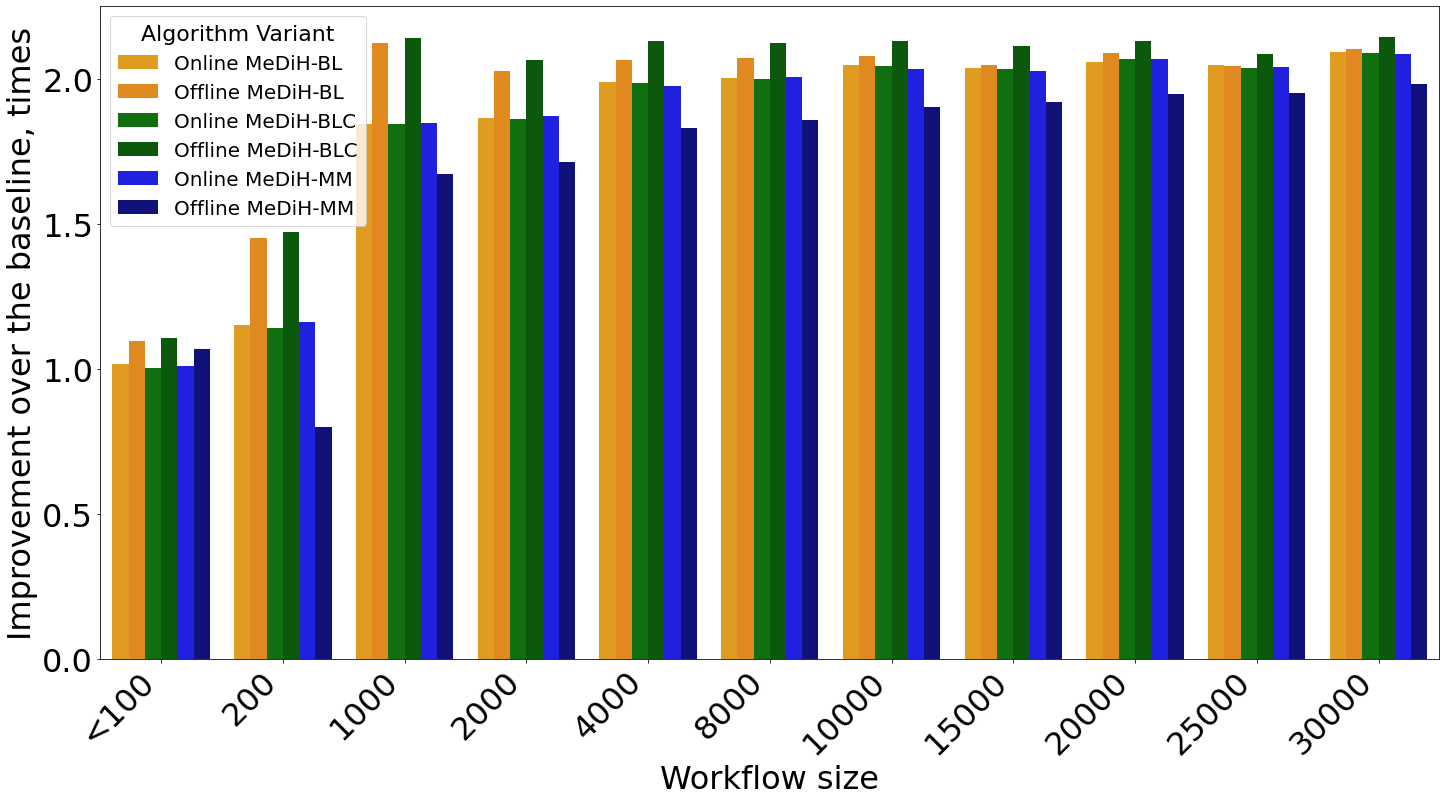

     size                   alg_rel     ratio
0     100    MeDiH-BL - dyn_vs_base  1.015898
1     100   MeDiH-BL - stat_vs_base  1.097715
2     100   MeDiH-BLC - dyn_vs_base  1.002949
3     100  MeDiH-BLC - stat_vs_base  1.107475
4     100    MeDiH-MM - dyn_vs_base  1.011067
..    ...                       ...       ...
61  30000   MeDiH-BL - stat_vs_base  2.102245
62  30000   MeDiH-BLC - dyn_vs_base  2.091309
63  30000  MeDiH-BLC - stat_vs_base  2.143272
64  30000    MeDiH-MM - dyn_vs_base  2.084874
65  30000   MeDiH-MM - stat_vs_base  1.982194

[66 rows x 3 columns]
alg_rel
MeDiH-BL - dyn_vs_base      1.786925
MeDiH-BL - stat_vs_base     1.893531
MeDiH-BLC - dyn_vs_base     1.781197
MeDiH-BLC - stat_vs_base    1.932681
MeDiH-MM - dyn_vs_base      1.784880
MeDiH-MM - stat_vs_base     1.639310
Name: ratio, dtype: float64
    algorithm size_group     ratio
3    MeDiH-BL      small  1.166662
2    MeDiH-BL     middle  1.076368
0    MeDiH-BL      large  1.009750
1    MeDiH-BL    largest  1

In [9]:
#//////////////// newest results 26/12/25 with new formula //////////////////////////
#//////////////////////NO DEVIATION

path = "./results-26-12/merged/*.txt"
#print(path)

patterndevs = r'^(BASE|A\d+)-(ndev)'

dfs26=read_dfs(path,patterndevs, 2)

#print(dfs)
dfsVar1 = [dfs26[('A1','ndev')], dfs26[('A2','ndev')], dfs26[('A3','ndev')], dfs26[('BASE','ndev')]]
#print(dfsVar1)
merged_df_var1 = merge_correct_columns(dfsVar1, labels)
#print(merged_df_var1)
plot_df = buld_plot_df(merged_df_var1)
plot_df = plot_df[plot_df["size"]!= 18000]

#print(plot_df)
#print(plot_df[
#    (plot_df['relation'] == 'internal') &
#    (plot_df['algorithm'] == 'MeDiH-BL') 
#   # & (~plot_df['wf_name'].str.contains('eager')) 
#   & (plot_df['ratio'] > 1.5)
#].to_string())



plotDynAndStaticVsBaseNoInset(plot_df, "no_deviations", "Makespan improvement over baseline, ", ['stat_vs_base', 'dyn_vs_base'])#

allInternals = plot_df[plot_df['relation']=='internal']
allInternals = allInternals.copy()
#print(allInternals.to_string())
# Add a new column for size group
allInternals['size_group'] = allInternals['size'].apply(size_category)
# Filter only valid categories
filtered = allInternals[allInternals['size_group'] != 'other']
# Group by algorithm and size_group, then compute geometric mean
result = filtered.groupby(['algorithm', 'size_group'])['ratio'].agg(gmean).reset_index()

# Optionally, sort the result

result['size_group'] = pd.Categorical(result['size_group'], categories=size_order, ordered=True)
result = result.sort_values(['algorithm', 'size_group'])

print(result)

result2 = filtered.groupby(['algorithm', 'size'])['ratio'].agg(gmean).reset_index()
print("!!!", result2)

by_algo = allInternals.groupby('algorithm')['ratio'].agg(gmean).reset_index()
print(by_algo)

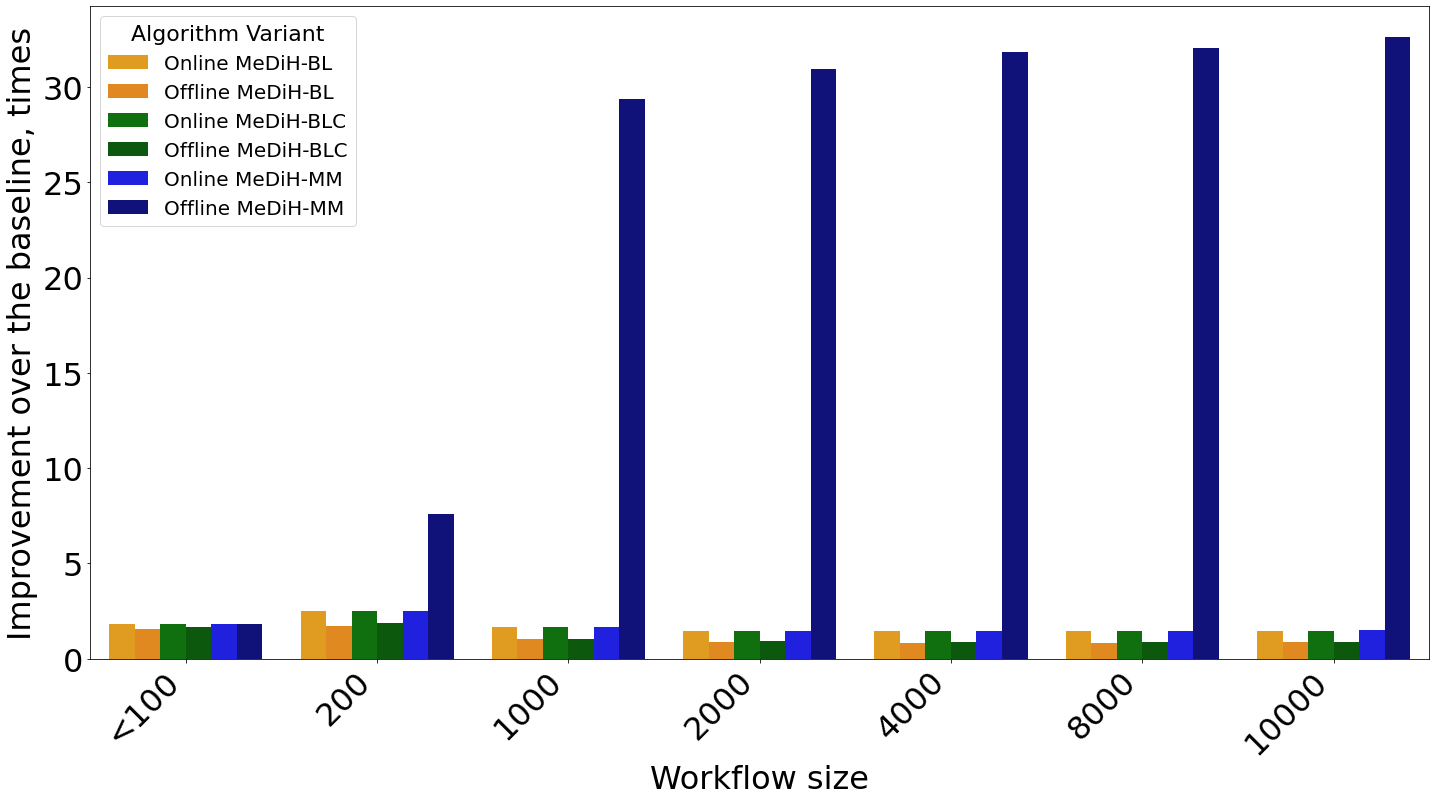

     size                   alg_rel      ratio
0     100    MeDiH-BL - dyn_vs_base   1.819718
1     100   MeDiH-BL - stat_vs_base   1.555502
2     100   MeDiH-BLC - dyn_vs_base   1.819579
3     100  MeDiH-BLC - stat_vs_base   1.662245
4     100    MeDiH-MM - dyn_vs_base   1.810079
5     100   MeDiH-MM - stat_vs_base   1.822831
6     200    MeDiH-BL - dyn_vs_base   2.524941
7     200   MeDiH-BL - stat_vs_base   1.743881
8     200   MeDiH-BLC - dyn_vs_base   2.521009
9     200  MeDiH-BLC - stat_vs_base   1.863120
10    200    MeDiH-MM - dyn_vs_base   2.486656
11    200   MeDiH-MM - stat_vs_base   7.619389
12   1000    MeDiH-BL - dyn_vs_base   1.663086
13   1000   MeDiH-BL - stat_vs_base   1.024510
14   1000   MeDiH-BLC - dyn_vs_base   1.690862
15   1000  MeDiH-BLC - stat_vs_base   1.047004
16   1000    MeDiH-MM - dyn_vs_base   1.664741
17   1000   MeDiH-MM - stat_vs_base  29.398045
18   2000    MeDiH-BL - dyn_vs_base   1.469168
19   2000   MeDiH-BL - stat_vs_base   0.901386
20   2000   M

In [8]:
#//////////////// Results after refactoring //////////////////////////
#//////////////////////NO DEVIATION

path = "./output-17-02-26/merged/*.txt"
#print(path)

patterndevs = r'^(BASE|A\d+)-(ndev)'

dfs26=read_dfs(path,patterndevs, 2)

#print(dfs)
dfsVar1 = [dfs26[('A1','ndev')], dfs26[('A2','ndev')], dfs26[('A3','ndev')], dfs26[('BASE','ndev')]]
#print(dfsVar1)
merged_df_var1 = merge_correct_columns(dfsVar1, labels)
#print(merged_df_var1)
plot_df = buld_plot_df(merged_df_var1)
plot_df = plot_df[plot_df["size"]!= 18000]

#print(plot_df)
#print(plot_df[
#    (plot_df['relation'] == 'internal') &
#    (plot_df['algorithm'] == 'MeDiH-BL') 
#   # & (~plot_df['wf_name'].str.contains('eager')) 
#   & (plot_df['ratio'] > 1.5)
#].to_string())



plotDynAndStaticVsBaseNoInset(plot_df, "no_deviations", "Makespan improvement over baseline, ", ['stat_vs_base', 'dyn_vs_base'])#

allInternals = plot_df[plot_df['relation']=='internal']
allInternals = allInternals.copy()
#print(allInternals.to_string())
# Add a new column for size group
allInternals['size_group'] = allInternals['size'].apply(size_category)
# Filter only valid categories
filtered = allInternals[allInternals['size_group'] != 'other']
# Group by algorithm and size_group, then compute geometric mean
result = filtered.groupby(['algorithm', 'size_group'])['ratio'].agg(gmean).reset_index()

# Optionally, sort the result

result['size_group'] = pd.Categorical(result['size_group'], categories=size_order, ordered=True)
result = result.sort_values(['algorithm', 'size_group'])

print(result)

result2 = filtered.groupby(['algorithm', 'size'])['ratio'].agg(gmean).reset_index()
print("!!!", result2)

by_algo = allInternals.groupby('algorithm')['ratio'].agg(gmean).reset_index()
print(by_algo)